# 🏠 House Price Prediction

## End-to-End Machine Learning Web Application

### Author

Andrew Asem

### Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- FastAPI
- React
- TypeScript

---

## Project Overview

This project aims to develop an end-to-end machine learning web application that predicts house prices based on property features.

The project includes:

- Data Exploration
- Data Cleaning
- Feature Engineering
- Model Training
- Model Evaluation
- FastAPI Backend
- React Frontend

The final solution will allow users to enter house information through a web interface and receive an estimated house price using the best-performing regression model.

#  Business Problem

Accurately estimating house prices is important for buyers, sellers, and real estate agencies.

Manual estimation is often subjective and time-consuming. Machine learning models can analyze historical housing data and learn relationships between property features and market prices, providing faster and more consistent price estimates.

#  Project Objectives

The objectives of this project are:

- Explore and understand the dataset.
- Clean and preprocess the data.
- Perform feature engineering.
- Train multiple regression models.
- Compare model performance.
- Select the best model.
- Build a FastAPI prediction API.
- Develop a React frontend for predictions.

#  Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

#  Load Dataset

In this section, we load the dataset into a pandas DataFrame and verify that it has been loaded correctly by displaying its dimensions and the first few rows.

In [2]:
# Load the dataset
df = pd.read_csv("data/house_prices.csv")

# Display dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display first 5 rows
df.head()

Rows: 187531
Columns: 21


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


#  Dataset Information

Understanding the dataset structure is the first step in any machine learning project.

We inspect:

- Number of rows and columns
- Data types
- Missing values
- Memory usage

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

#  Statistical Summary

The statistical summary provides an overview of the numerical features, including:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index,187531.0,93765.000000,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Price (in rupees),169866.0,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
Dimensions,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot Area,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#  Missing Values

Before building any model, we check whether the dataset contains missing values that need to be handled.

In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Plot Area      187531
Dimensions     187531
Society        109678
Super Area     107685
Car Parking    103357
                ...  
Description      3023
Furnishing       2897
Bathroom          828
Status            615
Transaction        83
Length: 17, dtype: int64

#  Duplicate Records

Duplicate records can negatively affect model performance. We check whether duplicate rows exist in the dataset.

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


#  Dataset Columns

Display all feature names before beginning exploratory data analysis.

In [9]:
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. Index
2. Title
3. Description
4. Amount(in rupees)
5. Price (in rupees)
6. location
7. Carpet Area
8. Status
9. Floor
10. Transaction
11. Furnishing
12. facing
13. overlooking
14. Society
15. Bathroom
16. Balcony
17. Car Parking
18. Ownership
19. Super Area
20. Dimensions
21. Plot Area


#  Data Dictionary

The following table summarizes the dataset columns, their data types, the percentage of missing values, and a brief description of their purpose in the project.

This helps us identify which features are useful, which require preprocessing, and which may need to be removed.

In [12]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

data_dictionary.reset_index(drop=True, inplace=True)

data_dictionary

,Column,Data Type,Missing Values,Missing (%)
0,Index,int64,0,0.00
1,Title,str,0,0.00
2,Description,str,3023,1.61
3,Amount(in rupees),str,0,0.00
4,Price (in rupees),float64,17665,9.42
...,...,...,...,...
16,Car Parking,str,103357,55.11
17,Ownership,str,65517,34.94
18,Super Area,str,107685,57.42
19,Dimensions,float64,187531,100.00


#  Feature Classification

Each feature is classified according to its role in the machine learning pipeline.

In [13]:
feature_info = pd.DataFrame({
    "Feature": df.columns,
    "Role": [
        "Identifier",          # Index
        "Text",
        "Text",
        "Target",
        "Numeric Feature",
        "Categorical",
        "Text Numeric",
        "Categorical",
        "Text Numeric",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Text Numeric",
        "Text Numeric",
        "Categorical",
        "Categorical",
        "Text Numeric",
        "Drop",
        "Drop"
    ]
})

feature_info

,Feature,Role
0,Index,Identifier
1,Title,Text
2,Description,Text
3,Amount(in rupees),Target
4,Price (in rupees),Numeric Feature
...,...,...
16,Car Parking,Categorical
17,Ownership,Categorical
18,Super Area,Text Numeric
19,Dimensions,Drop


#  Feature Engineering - Target Variable

The target variable (`Amount(in rupees)`) is stored as text using Indian numbering units such as **Lac** and **Cr**.

Before training a regression model, these values must be converted into numeric values representing the total price in Indian Rupees (INR).

Examples:

- 42 Lac → 4,200,000
- 1.40 Cr → 14,000,000

In [14]:
def convert_price(price):
    """
    Convert prices stored as text (e.g., '42 Lac', '1.40 Cr')
    into numeric values in Indian Rupees.
    """

    if pd.isna(price):
        return np.nan

    price = str(price).strip()

    if "Cr" in price:
        return float(price.replace("Cr", "").strip()) * 10_000_000

    elif "Lac" in price:
        return float(price.replace("Lac", "").strip()) * 100_000

    else:
        try:
            return float(price)
        except:
            return np.nan

## Apply the Conversion

Create a new numeric target column while preserving the original text column for reference.

In [15]:
df["Price_INR"] = df["Amount(in rupees)"].apply(convert_price)

df[["Amount(in rupees)", "Price_INR"]].head(10)

,Amount(in rupees),Price_INR
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


## Validate the Conversion

Verify that the conversion was performed correctly by checking summary statistics and sample values.

In [16]:
df["Price_INR"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: Price_INR, dtype: float64

# Validate the Target Variable

Before training any machine learning model, it is important to inspect the target variable for unusual or extreme values.

Outliers may represent:

- Luxury properties
- Data entry errors
- Incorrect unit conversions

We investigate these values before deciding how to handle them.

In [17]:
# Display the 10 most expensive properties

df.sort_values("Price_INR", ascending=False)[
    [
        "Amount(in rupees)",
        "Price_INR",
        "Title",
        "location"
    ]
].head(10)

,Amount(in rupees),Price_INR,Title,location
181234,1400.30 Cr,1.400300e+10,3 BHK Ready to Occupy Flat for sale in Nest Ha...,vadodara
176536,510.04 Cr,5.100400e+09,3 BHK Ready to Occupy Flat for sale Hill Cart ...,siliguri
174894,396.75 Cr,3.967500e+09,2 BHK Ready to Occupy Flat for sale Kachna Road,raipur
175013,229.80 Cr,2.298000e+09,2 BHK Ready to Occupy Flat for sale in Chaitan...,raipur
183303,80 Cr,8.000000e+08,Studio Apartment for sale Awleshpur chitaipur...,varanasi
51966,60 Cr,6.000000e+08,5 BHK Ready to Occupy Flat for sale in DLF The...,gurgaon
52058,55 Cr,5.500000e+08,4 BHK Ready to Occupy Flat for sale in DLF Cam...,gurgaon
50321,55 Cr,5.500000e+08,5 BHK Ready to Occupy Flat for sale in DLF The...,gurgaon
52387,52 Cr,5.200000e+08,5 BHK Ready to Occupy Flat for sale in DLF Cam...,gurgaon
51965,50 Cr,5.000000e+08,5 BHK Ready to Occupy Flat for sale Golf Cours...,gurgaon


#  Distribution of the Target Variable

Visualizing the target variable helps us understand:

- Distribution shape
- Presence of skewness
- Potential outliers

This information guides future preprocessing decisions.

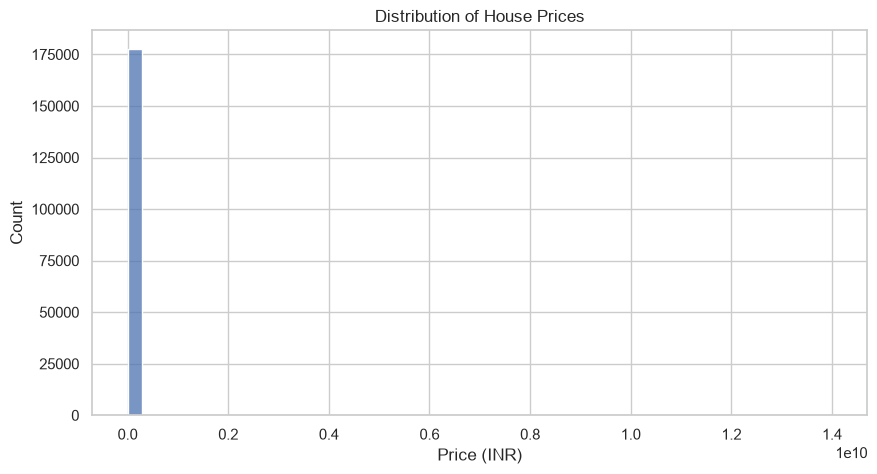

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Price_INR"], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Count")

plt.show()

#  Boxplot of the Target Variable

A boxplot provides a compact summary of the target variable and highlights potential outliers.

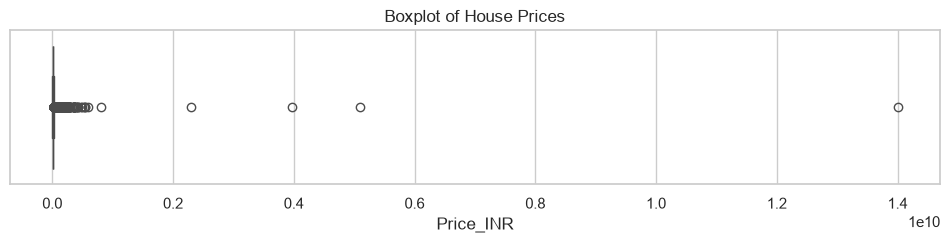

In [19]:
plt.figure(figsize=(12, 2))

sns.boxplot(x=df["Price_INR"])

plt.title("Boxplot of House Prices")

plt.show()

#  Log Transformation of the Target Variable

The house prices are highly right-skewed because a small number of luxury properties have extremely high prices.

To better visualize the distribution, we apply a logarithmic transformation.

The log transformation compresses very large values while preserving the ordering of the data, making the distribution easier to analyze.

In [20]:
df["Log_Price"] = np.log1p(df["Price_INR"])

## Distribution After Log Transformation

The following histogram shows the distribution after applying the logarithmic transformation.

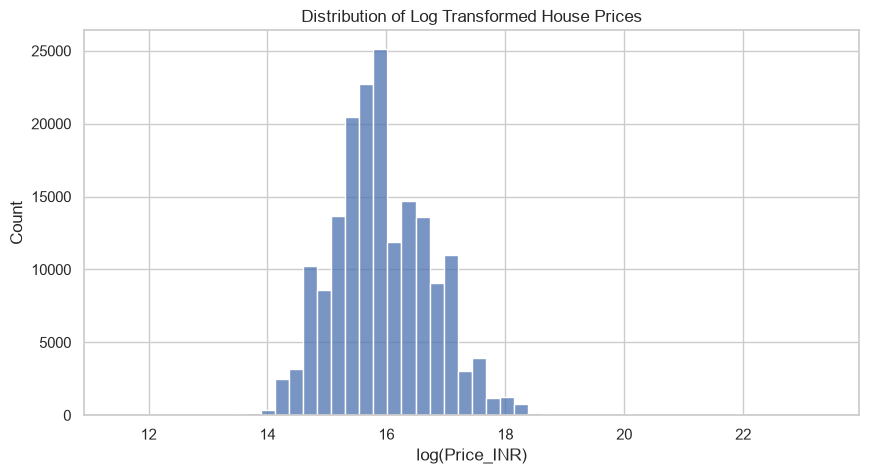

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["Log_Price"], bins=50)

plt.title("Distribution of Log Transformed House Prices")

plt.xlabel("log(Price_INR)")

plt.ylabel("Count")

plt.show()

## Boxplot After Log Transformation

The boxplot after logarithmic transformation provides a clearer visualization of the spread of the data.

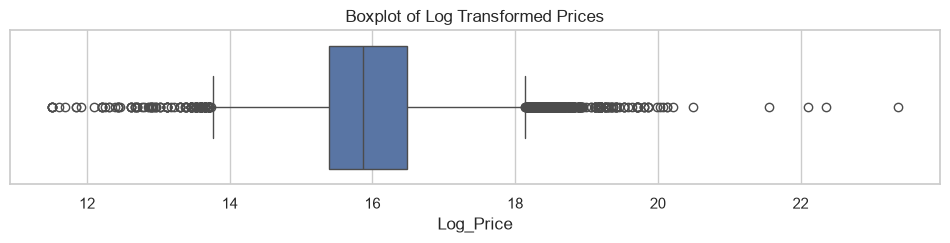

In [22]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["Log_Price"])

plt.title("Boxplot of Log Transformed Prices")

plt.show()

#  Observations

### Original Target Variable (`Price_INR`)

- The target variable was successfully converted from text (Lac/Cr) into numeric values (INR).
- The original distribution is highly right-skewed.
- Several extremely expensive properties produce significant outliers.
- These outliers compress the histogram, making the distribution difficult to interpret.

### Log-Transformed Target Variable (`Log_Price`)

- The logarithmic transformation significantly reduces the skewness.
- The distribution becomes much closer to a normal (bell-shaped) distribution.
- Outliers are still present but have much less influence on the visualization.
- Log transformation may improve the performance of regression models such as Linear Regression, Ridge, and Lasso.

### Conclusion

For exploratory analysis, the logarithmic transformation provides a much clearer view of the data distribution. During model development, we will compare models trained on both the original target and the log-transformed target to determine which produces better prediction accuracy.

#  Feature Engineering - Carpet Area

The `Carpet Area` feature represents the usable floor area of a property.

Since the values are stored as text (e.g., `500 sqft`), they must be converted into numeric values before they can be used in machine learning models.

A new column named `Carpet_Area_sqft` will be created while preserving the original feature.

In [23]:
def extract_carpet_area(area):
    """
    Extract the numeric value from the Carpet Area column.
    Example:
        '500 sqft' -> 500
    """

    if pd.isna(area):
        return np.nan

    area = str(area).lower().replace(",", "").strip()

    try:
        return float(area.replace("sqft", "").strip())
    except:
        return np.nan

## Apply the Transformation

Convert the textual carpet area into a numeric feature measured in square feet.

In [24]:
df["Carpet_Area_sqft"] = df["Carpet Area"].apply(extract_carpet_area)

df[
    [
        "Carpet Area",
        "Carpet_Area_sqft"
    ]
].head(10)

,Carpet Area,Carpet_Area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


## Validate the Transformation

Display summary statistics for the newly engineered feature.

In [25]:
df["Carpet_Area_sqft"].describe()

count    100428.000000
mean       1268.525909
std        3129.311735
min           1.000000
25%         801.000000
50%        1071.000000
75%        1500.000000
max      709222.000000
Name: Carpet_Area_sqft, dtype: float64

## Check Missing Values

Measure how many missing values remain after the conversion.

In [26]:
missing = df["Carpet_Area_sqft"].isna().sum()

percentage = (missing / len(df)) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {percentage:.2f}%")

Missing values : 87,103
Missing (%)    : 46.45%


#  Carpet Area Observations

Summarize the results obtained after converting the Carpet Area feature.

In [27]:
print(f"Minimum Area : {df['Carpet_Area_sqft'].min()} sqft")
print(f"Maximum Area : {df['Carpet_Area_sqft'].max()} sqft")
print(f"Average Area : {df['Carpet_Area_sqft'].mean():.2f} sqft")

Minimum Area : 1.0 sqft
Maximum Area : 709222.0 sqft
Average Area : 1268.53 sqft


#  Investigating Suspicious Carpet Area Values

The summary statistics revealed extremely small and extremely large carpet area values.

Before removing or modifying any records, these observations are investigated to determine whether they are valid properties or potential data quality issues.

In [28]:
# Smallest carpet areas

df.sort_values("Carpet_Area_sqft")[
    [
        "Title",
        "Carpet Area",
        "Carpet_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Carpet Area,Carpet_Area_sqft,Amount(in rupees),location
176967,2 BHK Ready to Occupy Flat for sale in The New...,1 sqft,1.0,25 Lac,sonipat
147727,3 BHK Ready to Occupy Flat for sale in Saptris...,1 sqft,1.0,Call for Price,agra
185837,3 BHK Ready to Occupy Flat for sale Madhurawada,1 sqft,1.0,70 Lac,visakhapatnam
172072,2 BHK Ready to Occupy Flat for sale in Yesh Fa...,1 sqft,1.0,35 Lac,mysore
148158,3 BHK Ready to Occupy Flat for sale George Town,2 sqft,2.0,68 Lac,allahabad
169827,3 BHK Ready to Occupy Flat for sale in Inland ...,5 sqft,5.0,2.2 Lac,mangalore
183490,2 BHK Ready to Occupy Flat for sale orderly ba...,12 sqft,12.0,35 Lac,varanasi
151038,4 BHK Ready to Occupy Flat for sale in Exotic ...,17 sqft,17.0,1.47 Cr,chandigarh
185376,2 BHK Ready to Occupy Flat for sale Pithapuram...,20 sqft,20.0,45 Lac,visakhapatnam
184633,2 BHK Ready to Occupy Flat for sale in Honeyy ...,20 sqft,20.0,47 Lac,visakhapatnam


## Largest Carpet Areas

Display the largest recorded carpet areas to inspect possible outliers.

In [29]:
df.sort_values("Carpet_Area_sqft", ascending=False)[
    [
        "Title",
        "Carpet Area",
        "Carpet_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Carpet Area,Carpet_Area_sqft,Amount(in rupees),location
165733,2 BHK Ready to Occupy Flat for sale Kahilipara,709222 sqft,709222.0,60 Lac,guwahati
149239,2 BHK Ready to Occupy Flat for sale Tapukara,495970 sqft,495970.0,19 Lac,bhiwadi
147580,3 BHK Ready to Occupy Flat for sale Fatehabad ...,282004 sqft,282004.0,20 Lac,agra
50895,3 BHK Ready to Occupy Flat for sale in TARC Ma...,194936 sqft,194936.0,2.60 Cr,gurgaon
147791,3 BHK Ready to Occupy Flat for sale in Aparna ...,113134 sqft,113134.0,56 Lac,agra
82876,3 BHK Ready to Occupy Flat for sale in Seven H...,107806 sqft,107806.0,68 Lac,jaipur
180072,2 BHK Ready to Occupy Flat for sale Velappaya,81845 sqft,81845.0,45 Lac,thrissur
176689,3 BHK Ready to Occupy Flat for sale Sevoke Road,81675 sqft,81675.0,45.7 Lac,siliguri
176690,2 BHK Ready to Occupy Flat for sale Sevoke Road,71775 sqft,71775.0,40.2 Lac,siliguri
176711,2 BHK Ready to Occupy Flat for sale Sevoke Road,71025 sqft,71025.0,39.8 Lac,siliguri


## Distribution of Carpet Area

Visualizing the carpet area helps identify skewness and potential outliers.

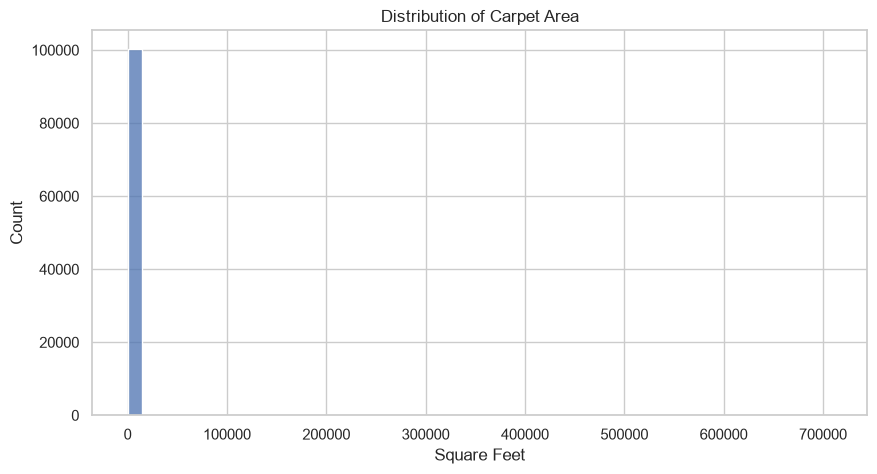

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(df["Carpet_Area_sqft"], bins=50)

plt.title("Distribution of Carpet Area")

plt.xlabel("Square Feet")

plt.ylabel("Count")

plt.show()

## Boxplot of Carpet Area

A boxplot highlights potential outliers in the Carpet Area feature.

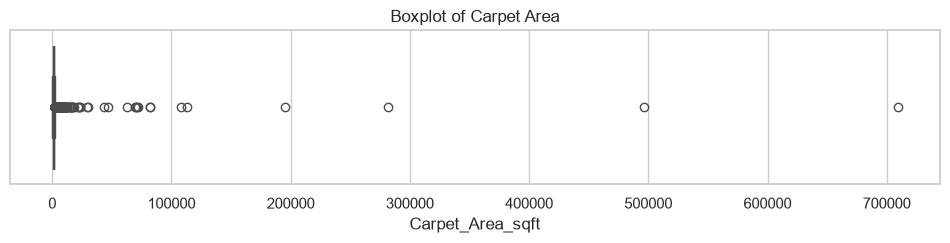

In [31]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["Carpet_Area_sqft"])

plt.title("Boxplot of Carpet Area")

plt.show()

#  Carpet Area Observations

Summarize the findings after inspecting the Carpet Area feature.

Possible points to discuss:

- Missing values
- Distribution
- Extreme values
- Potential data quality issues
- Planned preprocessing strategy

#  Carpet Area Percentile Analysis

Before deciding whether to remove extreme values, we analyze the distribution using percentiles.

Percentiles help identify the typical range of property sizes while minimizing the influence of extreme observations.

This approach provides an objective basis for handling outliers.

In [32]:
df["Carpet_Area_sqft"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.250     801.0
0.500    1071.0
0.750    1500.0
0.900    1950.0
0.950    2550.0
0.990    4583.0
0.995    4583.0
0.999    5700.0
Name: Carpet_Area_sqft, dtype: float64

#  Visualizing Carpet Area (Excluding Extreme Outliers)

To better understand the distribution of typical properties, we temporarily visualize carpet areas below the 99th percentile.

This visualization is used only for exploratory analysis and does not modify the dataset.

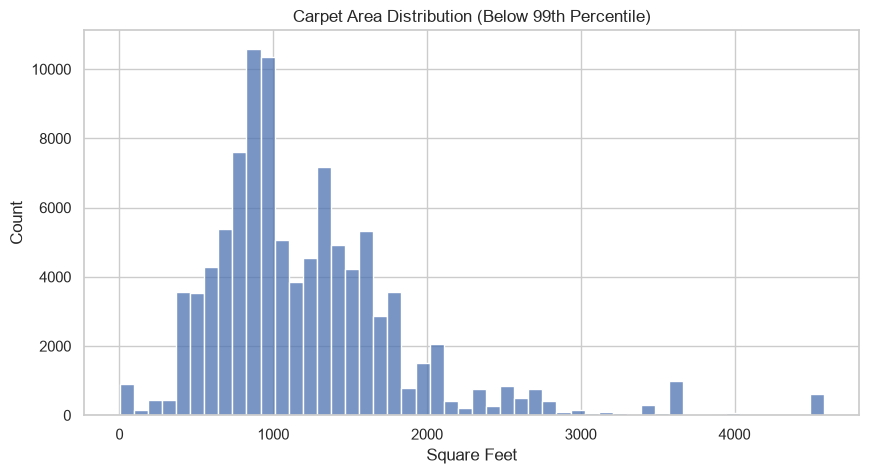

In [33]:
p99 = df["Carpet_Area_sqft"].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(
    df.loc[df["Carpet_Area_sqft"] <= p99, "Carpet_Area_sqft"],
    bins=50
)

plt.title("Carpet Area Distribution (Below 99th Percentile)")
plt.xlabel("Square Feet")
plt.ylabel("Count")

plt.show()

## Boxplot Below the 99th Percentile

The following visualization focuses on the majority of properties after excluding the most extreme observations.

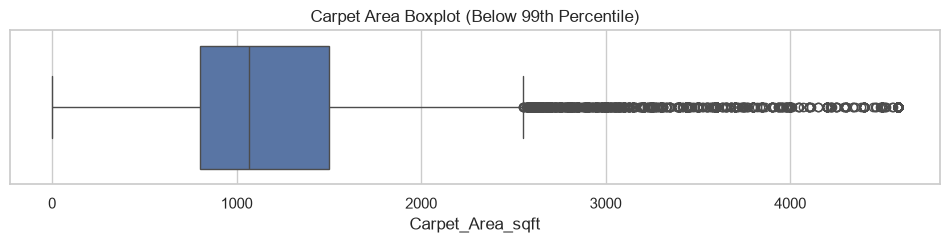

In [34]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=df.loc[df["Carpet_Area_sqft"] <= p99, "Carpet_Area_sqft"]
)

plt.title("Carpet Area Boxplot (Below 99th Percentile)")

plt.show()

# Observations

Summarize the percentile analysis.

Include:

- Typical carpet area range.
- Whether the extreme values appear realistic.
- Whether percentile-based filtering seems appropriate.
- Any insights from the histogram and boxplot after excluding the top 1%.

#  Cleaning Carpet Area

Based on the exploratory analysis:

- Carpet areas smaller than **100 sqft** are considered invalid.
- Carpet areas larger than the **99.9th percentile (5700 sqft)** are considered extreme outliers.

Instead of removing entire records, these values are replaced with missing values (`NaN`).

This preserves the remaining information for each property while preventing unrealistic values from influencing the model.

In [35]:
# Number of invalid values before cleaning

invalid_small = (df["Carpet_Area_sqft"] < 100).sum()

invalid_large = (df["Carpet_Area_sqft"] > 5700).sum()

print(f"Areas < 100 sqft : {invalid_small}")
print(f"Areas > 5700 sqft: {invalid_large}")

Areas < 100 sqft : 905
Areas > 5700 sqft: 99


In [36]:
# Replace unrealistic values with NaN

df.loc[df["Carpet_Area_sqft"] < 100, "Carpet_Area_sqft"] = np.nan

df.loc[df["Carpet_Area_sqft"] > 5700, "Carpet_Area_sqft"] = np.nan

## Validate the Cleaning

After replacing unrealistic values with missing values, verify the updated summary statistics.

In [37]:
df["Carpet_Area_sqft"].describe()

count    99424.000000
mean      1246.987277
std        688.046429
min        100.000000
25%        805.000000
50%       1086.000000
75%       1500.000000
max       5700.000000
Name: Carpet_Area_sqft, dtype: float64

In [38]:
print(f"Missing values : {df['Carpet_Area_sqft'].isna().sum():,}")

print(f"Missing (%) : {df['Carpet_Area_sqft'].isna().mean()*100:.2f}%")

Missing values : 88,107
Missing (%) : 46.98%


#  Observations

Summarize the results after cleaning the Carpet Area feature.

Suggested points:

- Invalid values were replaced with missing values.
- Extremely large outliers were removed based on the 99.9th percentile.
- The feature is now more suitable for future preprocessing and model training.

#  Feature Engineering - Super Area

The `Super Area` column represents the total built-up area of a property.

Like the Carpet Area feature, it is stored as text and must be converted into a numeric feature before it can be used in machine learning models.

A new column named `Super_Area_sqft` will be created while preserving the original feature.

In [39]:
def extract_super_area(area):
    """
    Extract the numeric value from the Super Area column.

    Example:
        '1200 sqft' -> 1200
    """

    if pd.isna(area):
        return np.nan

    area = str(area).lower().replace(",", "").strip()

    try:
        return float(area.replace("sqft", "").strip())
    except:
        return np.nan

## Apply the Transformation

Convert the textual Super Area values into numeric square feet.

In [40]:
df["Super_Area_sqft"] = df["Super Area"].apply(extract_super_area)

df[
    [
        "Super Area",
        "Super_Area_sqft"
    ]
].head(10)

,Super Area,Super_Area_sqft
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,680 sqft,680.0
6,NaN,NaN
7,575 sqft,575.0
8,600 sqft,600.0
9,NaN,NaN


## Validate the Transformation

Generate descriptive statistics for the engineered feature.

In [41]:
df["Super_Area_sqft"].describe()

count    75406.000000
mean      1385.678328
std        749.161278
min          1.000000
25%       1000.000000
50%       1300.000000
75%       1687.000000
max      40000.000000
Name: Super_Area_sqft, dtype: float64

## Check Missing Values

Measure the amount of missing data in the new feature.


In [42]:
missing = df["Super_Area_sqft"].isna().sum()

percentage = missing / len(df) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {percentage:.2f}%")

Missing values : 112,125
Missing (%)    : 59.79%


#  Investigating Super Area

Inspect the smallest and largest values to identify possible data quality issues before cleaning.

In [43]:
# Smallest values

df.sort_values("Super_Area_sqft")[
    [
        "Title",
        "Super Area",
        "Super_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Super Area,Super_Area_sqft,Amount(in rupees),location
180679,2 BHK Ready to Occupy Flat for sale Fatehpura,1 sqft,1.0,45 Lac,udaipur
180481,3 BHK Ready to Occupy Flat for sale Sreekaryam,12 sqft,12.0,1.44 Cr,trivandrum
166174,1 BHK Ready to Occupy Flat for sale Bhoopatwal...,24 sqft,24.0,10 Lac,haridwar
166172,1 BHK Ready to Occupy Flat for sale Bhoopatwal...,24 sqft,24.0,10 Lac,haridwar
4908,1 BHK Ready to Occupy Flat for sale in Dhara A...,27 sqft,27.0,Call for Price,ahmedabad
143664,"1 BHK Ready to Occupy Flat for sale Sector 93,...",28 sqft,28.0,8 Lac,noida
177240,1 BHK Ready to Occupy Flat for sale Fazilpur V...,29 sqft,29.0,8 Lac,sonipat
5255,1 BHK Ready to Occupy Flat for sale Hathijan,29 sqft,29.0,9 Lac,ahmedabad
148122,1 BHK Ready to Occupy Flat for sale Nasibur ba...,35 sqft,35.0,15 Lac,allahabad
176409,2 BHK Ready to Occupy Flat for sale Kasumpti,38 sqft,38.0,Call for Price,shimla


In [44]:
# Largest values

df.sort_values("Super_Area_sqft", ascending=False)[
    [
        "Title",
        "Super Area",
        "Super_Area_sqft",
        "Amount(in rupees)",
        "location"
    ]
].head(10)

,Title,Super Area,Super_Area_sqft,Amount(in rupees),location
16963,Studio Apartment for sale Halanayakanahalli,"40,000 sqft",40000.0,16 Cr,bangalore
175087,1 BHK Ready to Occupy Flat for sale Sejbahar,"37,952 sqft",37952.0,8 Lac,raipur
17562,> 10 BHK Ready to Occupy Flat for sale Phase 1...,"36,000 sqft",36000.0,12 Cr,bangalore
71001,> 10 BHK Ready to Occupy Flat for sale in Jyot...,"25,000 sqft",25000.0,12 Cr,hyderabad
117232,> 10 BHK Ready to Occupy Flat for sale in Godr...,"25,000 sqft",25000.0,Call for Price,new-delhi
51094,> 10 BHK Ready to Occupy Flat for sale in DLF ...,"20,000 sqft",20000.0,Call for Price,gurgaon
71491,10 BHK Ready to Occupy Flat for sale in Positi...,"20,000 sqft",20000.0,10 Cr,hyderabad
183303,Studio Apartment for sale Awleshpur chitaipur...,"20,000 sqft",20000.0,80 Cr,varanasi
176489,3 BHK Ready to Occupy Flat for sale hakimpara ...,"18,000 sqft",18000.0,75 Lac,siliguri
2314,> 10 BHK Ready to Occupy Flat for sale in LIVA...,"15,000 sqft",15000.0,36 Cr,mumbai


#  Visualizing Super Area

Visualize the distribution of the engineered feature.

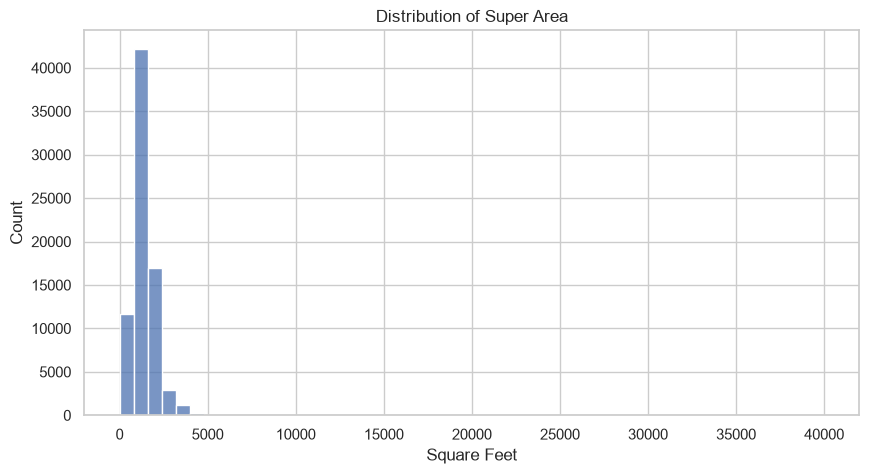

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(df["Super_Area_sqft"], bins=50)

plt.title("Distribution of Super Area")

plt.xlabel("Square Feet")

plt.ylabel("Count")

plt.show()

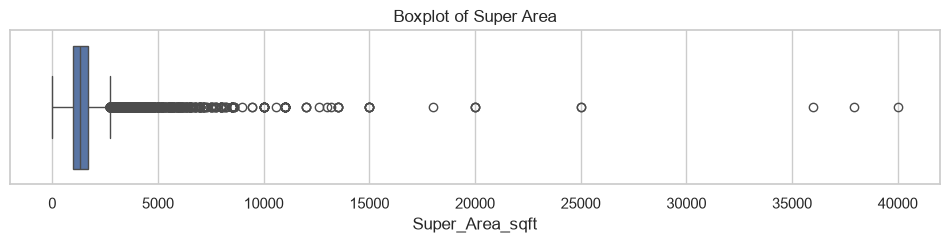

In [46]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["Super_Area_sqft"])

plt.title("Boxplot of Super Area")

plt.show()

#  Cleaning Super Area

The extracted Super Area feature contains some impossible values.

Examples such as 1 sqft, 12 sqft and 24 sqft are clearly invalid.

Properties smaller than 100 sqft are removed.

Large properties are kept because luxury villas and estates can legitimately exceed 10,000 square feet.

In [47]:
# Remove impossible Super Area values

df.loc[df["Super_Area_sqft"] < 100, "Super_Area_sqft"] = np.nan

print("Remaining values:")
print(df["Super_Area_sqft"].describe())

print()
print("Missing values :", df["Super_Area_sqft"].isna().sum())
print(
    "Missing (%) :",
    round(df["Super_Area_sqft"].isna().mean() * 100, 2),
    "%"
)

Remaining values:
count    75362.000000
mean      1386.451912
std        748.695089
min        100.000000
25%       1000.000000
50%       1300.000000
75%       1689.750000
max      40000.000000
Name: Super_Area_sqft, dtype: float64

Missing values : 112169
Missing (%) : 59.81 %


### Observation

- Invalid Super Area values smaller than 100 sqft were identified as data entry errors and replaced with missing values.

- Extremely large properties were retained because luxury villas, estates, and commercial-style residential buildings can legitimately have very large built-up areas.

- After cleaning, the minimum valid Super Area became 100 sqft.

- The feature still contains approximately 60% missing values, which will be addressed later during the preprocessing and feature engineering stages.

#  Cleaning Bathroom Feature

The Bathroom column is stored as text and contains missing values.

The objective of this step is to:

- Convert the values into numeric format.
- Detect invalid entries.
- Understand the distribution.
- Prepare the feature for future preprocessing.

In [48]:
# Display sample values

df["Bathroom"].head(10)

0    1
1    2
2    2
3    1
4    2
5    1
6    1
7    1
8    1
9    3
Name: Bathroom, dtype: str

### Converting Bathroom to Numeric

In [49]:
# Convert Bathroom into numeric

df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

print(df["Bathroom"].describe())

print()

print("Missing values :", df["Bathroom"].isna().sum())
print(
    "Missing (%) :",
    round(df["Bathroom"].isna().mean() * 100, 2),
    "%"
)

count    186668.000000
mean          2.426640
std           0.863244
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: Bathroom, dtype: float64

Missing values : 863
Missing (%) : 0.46 %


### Bathroom Distribution

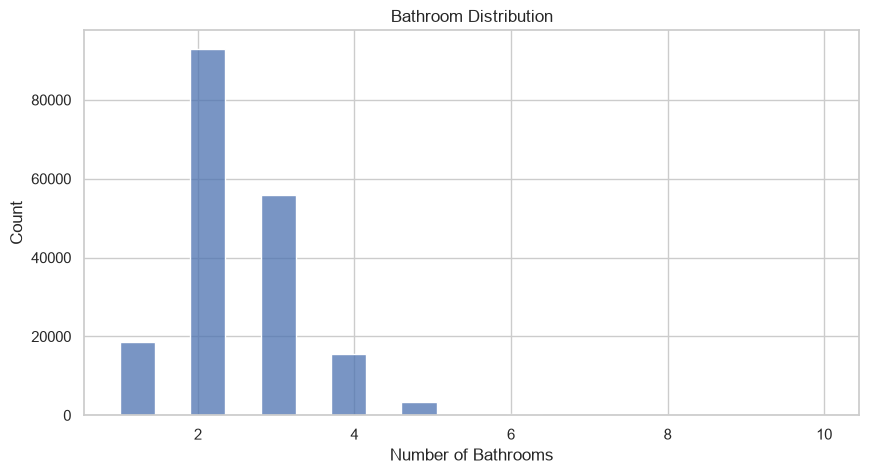

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(df["Bathroom"], bins=20)

plt.title("Bathroom Distribution")

plt.xlabel("Number of Bathrooms")

plt.ylabel("Count")

plt.show()

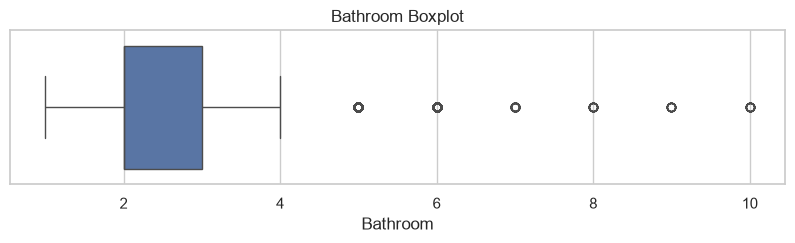

In [51]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Bathroom"])

plt.title("Bathroom Boxplot")

plt.show()

In [52]:
# Frequency table

df["Bathroom"].value_counts().sort_index()

Bathroom
1.0     18654
2.0     93007
3.0     55781
4.0     15600
5.0      3343
6.0       209
7.0        35
8.0        14
9.0        11
10.0       14
Name: count, dtype: int64

In [53]:
# Smallest values

df.nsmallest(
    10,
    "Bathroom"
)[
    [
        "Title",
        "Bathroom",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Bathroom,Amount(in rupees),location
0,1 BHK Ready to Occupy Flat for sale in Srushti...,1.0,42 Lac,thane
3,1 BHK Ready to Occupy Flat for sale Kasheli,1.0,25 Lac,thane
5,1 BHK Ready to Occupy Flat for sale in Virat A...,1.0,45 Lac,thane
6,1 BHK Ready to Occupy Flat for sale Mumbra,1.0,16.5 Lac,thane
7,1 BHK Ready to Occupy Flat for sale Kalwa,1.0,60 Lac,thane
8,1 BHK Ready to Occupy Flat for sale Kalwa,1.0,60 Lac,thane
14,1 BHK Ready to Occupy Flat for sale Rabodi,1.0,75 Lac,thane
16,1 BHK Ready to Occupy Flat for sale in Green W...,1.0,37 Lac,thane
17,1 BHK Ready to Occupy Flat for sale Dombivli West,1.0,35 Lac,thane
19,1 BHK Ready to Occupy Flat for sale Shahad,1.0,35 Lac,thane


In [54]:
# Largest values

df.nlargest(
    10,
    "Bathroom"
)[
    [
        "Title",
        "Bathroom",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Bathroom,Amount(in rupees),location
538,6 BHK Ready to Occupy Flat for sale in Courtya...,10.0,Call for Price,thane
2124,7 BHK Ready to Occupy Flat for sale in Lodha M...,10.0,22 Cr,mumbai
15853,10 BHK Ready to Occupy Flat for sale Hsr Layout,10.0,3.80 Cr,bangalore
39936,10 BHK Ready to Occupy Flat for sale in Guduva...,10.0,2.23 Cr,chennai
40728,10 BHK Ready to Occupy Flat for sale Guduvancheri,10.0,1.30 Cr,chennai
72128,> 10 BHK Ready to Occupy Flat for sale Sri Kri...,10.0,9 Cr,hyderabad
72458,> 10 BHK Ready to Occupy Flat for sale in Mani...,10.0,3.20 Cr,hyderabad
72582,4 BHK Ready to Occupy Flat for sale in Jains C...,10.0,1.96 Cr,hyderabad
84174,10 BHK Ready to Occupy Flat for sale Lalarpura,10.0,2.75 Cr,jaipur
114615,7 BHK Ready to Occupy Flat for sale in Lodha M...,10.0,22 Cr,mumbai


#  Bathroom Feature Assessment

The Bathroom feature was examined to identify missing values, invalid entries, and unusual observations.

Unlike the area-related features, the Bathroom feature appears to be highly consistent and requires no cleaning.

In [55]:
print("No cleaning was applied to the Bathroom feature.")

print()

print("Minimum Bathrooms :", df["Bathroom"].min())
print("Maximum Bathrooms :", df["Bathroom"].max())

print()

print("Missing values :", df["Bathroom"].isna().sum())
print(
    "Missing (%) :",
    round(df["Bathroom"].isna().mean() * 100, 2),
    "%"
)

No cleaning was applied to the Bathroom feature.

Minimum Bathrooms : 1.0
Maximum Bathrooms : 10.0

Missing values : 863
Missing (%) : 0.46 %


### Observation

- The Bathroom feature contains only 0.46% missing values, making it one of the most complete features in the dataset.

- All observed values are realistic, ranging from 1 to 10 bathrooms.

- Properties with a large number of bathrooms correspond to luxury or very large residential buildings and were therefore retained.

- No cleaning was required for this feature. Missing values will be handled later during the preprocessing stage.

#  Exploring and Cleaning the Balcony Feature

The Balcony feature represents the number of balconies available in a property.

In this section, we will:

- Inspect the feature.
- Convert it into a numeric format.
- Analyze missing values.
- Detect invalid values.
- Decide whether any cleaning is required.

In [56]:
# Display sample values

df["Balcony"].head(10)

0      2
1    NaN
2    NaN
3      1
4    NaN
5      1
6    NaN
7    NaN
8    NaN
9      1
Name: Balcony, dtype: str

### Converting Balcony to Numeric

In [57]:
# Convert Balcony to numeric

df["Balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

print(df["Balcony"].describe())

print()

print("Missing values :", df["Balcony"].isna().sum())
print(
    "Missing (%) :",
    round(df["Balcony"].isna().mean() * 100, 2),
    "%"
)

count    138574.000000
mean          2.000354
std           0.951430
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: Balcony, dtype: float64

Missing values : 48957
Missing (%) : 26.11 %


### Balcony Distribution

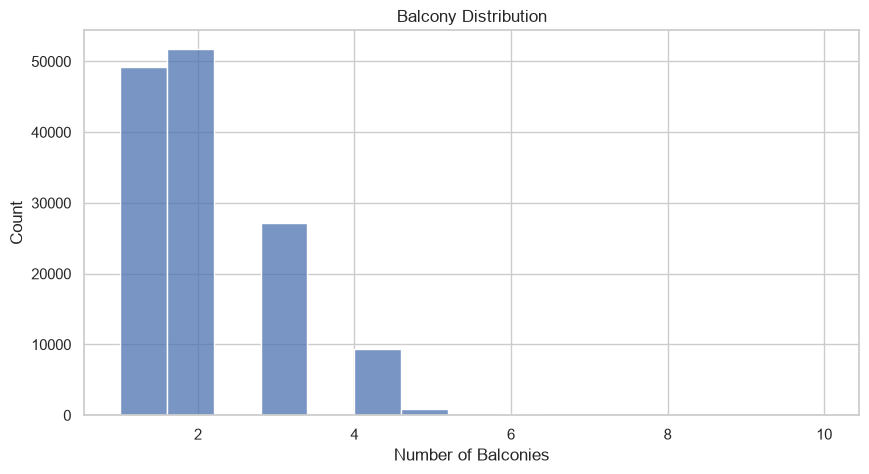

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(df["Balcony"], bins=15)

plt.title("Balcony Distribution")

plt.xlabel("Number of Balconies")

plt.ylabel("Count")

plt.show()

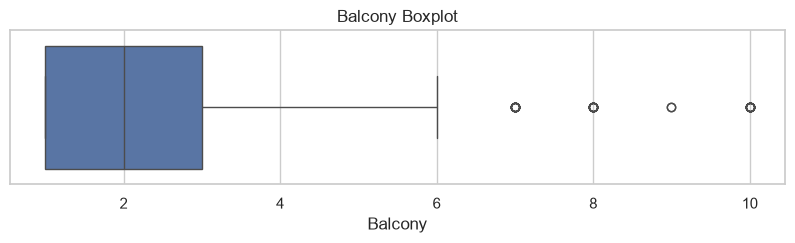

In [59]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Balcony"])

plt.title("Balcony Boxplot")

plt.show()

### Frequency of Balcony Values

In [60]:
df["Balcony"].value_counts().sort_index()

Balcony
1.0     49219
2.0     51809
3.0     27111
4.0      9420
5.0       841
6.0       132
7.0        14
8.0        13
9.0         2
10.0       13
Name: count, dtype: int64

### Smallest Balcony Values

In [61]:
df.nsmallest(
    10,
    "Balcony"
)[
    [
        "Title",
        "Balcony",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Balcony,Amount(in rupees),location
3,1 BHK Ready to Occupy Flat for sale Kasheli,1.0,25 Lac,thane
5,1 BHK Ready to Occupy Flat for sale in Virat A...,1.0,45 Lac,thane
9,3 BHK Ready to Occupy Flat for sale in Pride P...,1.0,1.60 Cr,thane
13,4 BHK Ready to Occupy Flat for sale Hiranandan...,1.0,4.25 Cr,thane
15,2 BHK Ready to Occupy Flat for sale in Puranik...,1.0,90 Lac,thane
19,1 BHK Ready to Occupy Flat for sale Shahad,1.0,35 Lac,thane
23,3 BHK Ready to Occupy Flat for sale in Tierra ...,1.0,1.28 Cr,thane
26,1 BHK Ready to Occupy Flat for sale in Xrbia W...,1.0,24 Lac,thane
29,1 BHK Ready to Occupy Flat for sale in Balaji ...,1.0,47 Lac,thane
30,4 BHK Ready to Occupy Flat for sale in Hiranan...,1.0,3.20 Cr,thane


### Largest Balcony Values

In [62]:
df.nlargest(
    10,
    "Balcony"
)[
    [
        "Title",
        "Balcony",
        "Amount(in rupees)",
        "location"
    ]
]

,Title,Balcony,Amount(in rupees),location
1952,8 BHK Ready to Occupy Flat for sale in Sunteck...,10.0,36.80 Cr,mumbai
15853,10 BHK Ready to Occupy Flat for sale Hsr Layout,10.0,3.80 Cr,bangalore
51023,3 BHK Ready to Occupy Flat for sale in M3M Gol...,10.0,4.16 Cr,gurgaon
51751,4 BHK Ready to Occupy Flat for sale in Pioneer...,10.0,7.50 Cr,gurgaon
82639,3 BHK Ready to Occupy Flat for sale in Balaji ...,10.0,63 Lac,jaipur
114443,8 BHK Ready to Occupy Flat for sale in Sunteck...,10.0,36.80 Cr,mumbai
115771,4 BHK Ready to Occupy Flat for sale Timarpur,10.0,4 Cr,new-delhi
116930,3 BHK Ready to Occupy Flat for sale in Saral A...,10.0,1.75 Cr,new-delhi
147580,3 BHK Ready to Occupy Flat for sale Fatehabad ...,10.0,20 Lac,agra
153451,3 BHK Ready to Occupy Flat for sale in Sikka K...,10.0,1.22 Cr,dehradun


#  Balcony Feature Assessment

The Balcony feature was examined to identify missing values, unrealistic observations, and potential outliers.

The feature appears consistent and does not require value correction or outlier removal.

In [63]:
print("No cleaning was applied to the Balcony feature.")

print()

print("Minimum Balconies :", df["Balcony"].min())
print("Maximum Balconies :", df["Balcony"].max())

print()

print("Missing values :", df["Balcony"].isna().sum())
print(
    "Missing (%) :",
    round(df["Balcony"].isna().mean() * 100, 2),
    "%"
)

No cleaning was applied to the Balcony feature.

Minimum Balconies : 1.0
Maximum Balconies : 10.0

Missing values : 48957
Missing (%) : 26.11 %


### Observation

- The Balcony feature contains approximately 26% missing values, which will be handled during the preprocessing stage.

- All observed balcony counts range from 1 to 10 and are considered realistic for residential properties.

- Properties with a large number of balconies correspond to luxury apartments or very large houses and were therefore retained.

- No cleaning or outlier removal was required for this feature.

#  Exploring Property Information Features

The following categorical features describe the legal and construction status of each property:

- Status
- Transaction
- Ownership

The objective is to:

- Inspect missing values.
- Identify the available categories.
- Detect inconsistent labels.
- Decide whether any cleaning is required before encoding.

### Status Feature

In [64]:
print("Missing values :", df["Status"].isna().sum())
print(
    "Missing (%) :",
    round(df["Status"].isna().mean() * 100, 2),
    "%"
)

print("\nUnique values:", df["Status"].nunique())

display(df["Status"].value_counts(dropna=False))

Missing values : 615
Missing (%) : 0.33 %

Unique values: 1


Status
Ready to Move    186916
NaN                 615
Name: count, dtype: int64

### Transaction Feature

In [65]:
print("Missing values :", df["Transaction"].isna().sum())
print(
    "Missing (%) :",
    round(df["Transaction"].isna().mean() * 100, 2),
    "%"
)

print("\nUnique values:", df["Transaction"].nunique())

display(df["Transaction"].value_counts(dropna=False))

Missing values : 83
Missing (%) : 0.04 %

Unique values: 4


Transaction
Resale          144172
New Property     42565
Other              709
NaN                 83
Rent/Lease           2
Name: count, dtype: int64

### Ownership Feature

In [66]:
print("Missing values :", df["Ownership"].isna().sum())
print(
    "Missing (%) :",
    round(df["Ownership"].isna().mean() * 100, 2),
    "%"
)

print("\nUnique values:", df["Ownership"].nunique())

display(df["Ownership"].value_counts(dropna=False))

Missing values : 65517
Missing (%) : 34.94 %

Unique values: 4


Ownership
Freehold                112229
NaN                      65517
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

### Summary of Property Information Features

In [67]:
summary = pd.DataFrame({
    "Feature": ["Status", "Transaction", "Ownership"],
    "Missing": [
        df["Status"].isna().sum(),
        df["Transaction"].isna().sum(),
        df["Ownership"].isna().sum()
    ],
    "Missing (%)": [
        round(df["Status"].isna().mean()*100,2),
        round(df["Transaction"].isna().mean()*100,2),
        round(df["Ownership"].isna().mean()*100,2)
    ],
    "Unique Categories": [
        df["Status"].nunique(),
        df["Transaction"].nunique(),
        df["Ownership"].nunique()
    ]
})

summary

,Feature,Missing,Missing (%),Unique Categories
0,Status,615,0.33,1
1,Transaction,83,0.04,4
2,Ownership,65517,34.94,4


## Status, Transaction, and Ownership Analysis

These categorical features describe the legal and selling status of the property.

We will inspect:

- Missing values
- Number of unique categories
- Category frequencies

This helps determine whether each feature is informative enough to keep for modeling.

In [68]:
categorical_features = ["Status", "Transaction", "Ownership"]

for feature in categorical_features:
    print("=" * 60)
    print(feature)

    missing = df[feature].isna().sum()
    percent = missing / len(df) * 100

    print(f"\nMissing values : {missing:,}")
    print(f"Missing (%)    : {percent:.2f}%")

    print(f"\nUnique values: {df[feature].nunique(dropna=True)}")

    print("\nValue Counts:\n")
    print(df[feature].value_counts(dropna=False))

    print()

Status

Missing values : 615
Missing (%)    : 0.33%

Unique values: 1

Value Counts:

Status
Ready to Move    186916
NaN                 615
Name: count, dtype: int64

Transaction

Missing values : 83
Missing (%)    : 0.04%

Unique values: 4

Value Counts:

Transaction
Resale          144172
New Property     42565
Other              709
NaN                 83
Rent/Lease           2
Name: count, dtype: int64

Ownership

Missing values : 65,517
Missing (%)    : 34.94%

Unique values: 4

Value Counts:

Ownership
Freehold                112229
NaN                      65517
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64



### Observation

### Status

- Almost every property is labeled **Ready to Move**.
- Only one meaningful category exists.
- Since the feature has no variation, it provides almost no predictive value.
- This feature will likely be removed during preprocessing.

### Transaction

- Most properties are **Resale**.
- A considerable number are **New Property**.
- Other categories are very rare.
- Missing values are negligible.
- This feature may contain useful predictive information and will be retained.

### Ownership

- Freehold dominates the dataset.
- Around 35% of the values are missing.
- Despite the missing values, ownership type may influence property prices.
- This feature will be kept and missing values will be handled during preprocessing.

## Furnishing Analysis

The furnishing status indicates how much furniture and interior finishing is included with the property.

Common categories include:

- Unfurnished
- Semi-Furnished
- Furnished

Since furnishing often affects selling price, we will inspect:

- Missing values
- Category distribution
- Number of unique categories

In [69]:
# Missing values

missing = df["Furnishing"].isna().sum()
missing_percent = missing / len(df) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {missing_percent:.2f}%")

print("\nUnique values:", df["Furnishing"].nunique())

print("\nValue Counts:\n")
print(df["Furnishing"].value_counts(dropna=False))

Missing values : 2,897
Missing (%)    : 1.54%

Unique values: 3

Value Counts:

Furnishing
Semi-Furnished    88318
Unfurnished       76154
Furnished         20162
NaN                2897
Name: count, dtype: int64


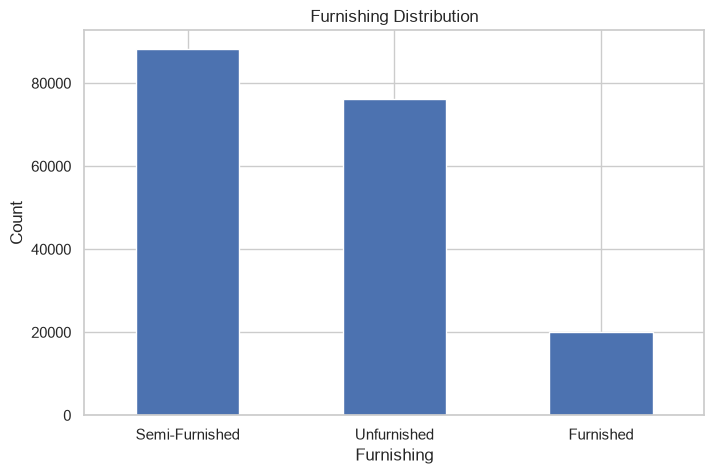

In [86]:
furnishing_counts = df["Furnishing"].value_counts()

plt.figure(figsize=(8, 5))
furnishing_counts.plot(kind="bar")

plt.title("Furnishing Distribution")
plt.xlabel("Furnishing")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

### Observation

- The feature contains only **1.54% missing values**, which is very low.

- The dataset contains **three furnishing categories**:
  - Semi-Furnished
  - Unfurnished
  - Furnished

- **Semi-Furnished** is the most common category, followed by **Unfurnished**, while **Furnished** properties are the least common.

- The distribution is balanced enough for machine learning models to learn meaningful patterns.

- Since furnishing level can significantly influence property prices, this feature will be retained and the small number of missing values will be handled during preprocessing.

## Facing Analysis

The **Facing** feature indicates the direction that the main entrance or front of the property faces.

Common directions include:

- East
- West
- North
- South

Some properties may also face intermediate directions such as North-East or South-West.

We will examine:

- Missing values
- Number of unique categories
- Category distribution
- Frequency of each direction

In [71]:
# Missing values

missing = df["facing"].isna().sum()
missing_percent = missing / len(df) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {missing_percent:.2f}%")

print("\nUnique values:", df["facing"].nunique())

print("\nValue Counts:\n")
print(df["facing"].value_counts(dropna=False))

Missing values : 70,233
Missing (%)    : 37.45%

Unique values: 8

Value Counts:

facing
NaN             70233
East            54741
North - East    24220
North           16533
West             8574
South            4694
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64


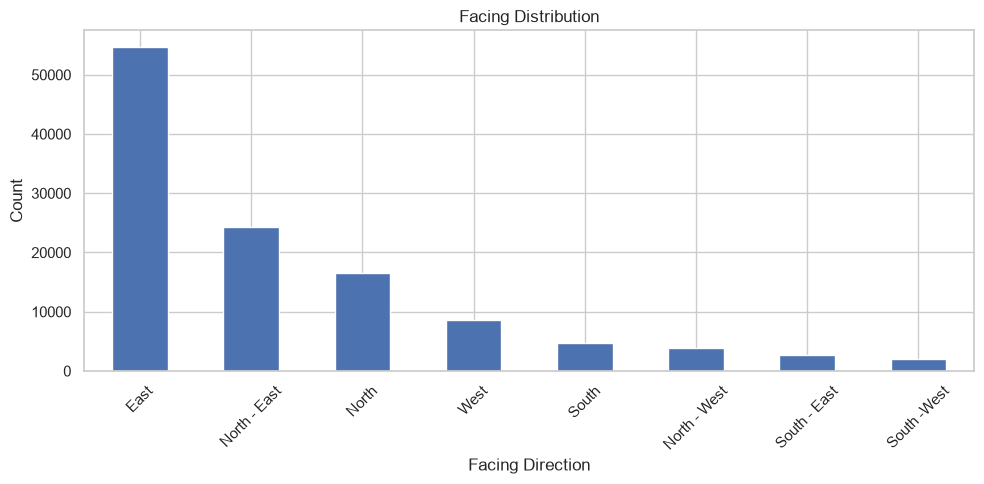

In [85]:
facing_counts = df["facing"].value_counts()

plt.figure(figsize=(10, 5))
facing_counts.plot(kind="bar")

plt.title("Facing Distribution")
plt.xlabel("Facing Direction")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation

- The feature contains **37.45% missing values**, which is relatively high.

- There are **8 unique facing directions** in the dataset.

- **East** is by far the most common facing direction, followed by **North-East** and **North**.

- West and South are less common, while the diagonal directions (North-West, South-East, and South-West) appear less frequently.

- Despite the high percentage of missing values, the feature may still provide useful information because property orientation can influence buyer preference and market value.

- The missing values will be handled later during preprocessing, and the feature will be retained for modeling.

## Car Parking Analysis

The **Car Parking** feature describes the parking facilities available for a property.

Parking availability is an important factor affecting both property value and buyer preference.

We will examine:

- Missing values
- Number of unique categories
- Frequency of each parking type
- Distribution of parking availability

In [73]:
# Missing values

missing = df["Car Parking"].isna().sum()
missing_percent = missing / len(df) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {missing_percent:.2f}%")

print("\nUnique values:", df["Car Parking"].nunique())

print("\nValue Counts:\n")
print(df["Car Parking"].value_counts(dropna=False))

Missing values : 103,357
Missing (%)    : 55.11%

Unique values: 229

Value Counts:

Car Parking
NaN            103357
1 Covered       38754
1 Covered,      16991
2 Covered       10691
1 Open           7873
                ...  
104 Covered         1
205 Covered         1
11 Covered,         1
403 Covered         1
702 Open            1
Name: count, Length: 230, dtype: int64


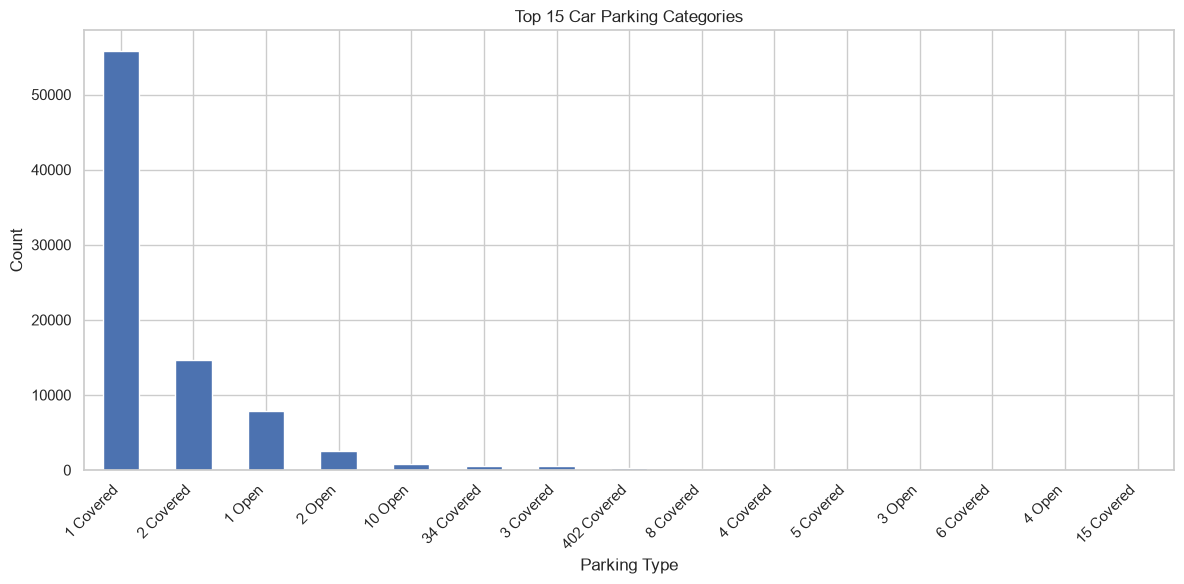

In [84]:
parking_counts = df["Car Parking"].value_counts().head(15)

plt.figure(figsize=(12, 6))
parking_counts.plot(kind="bar")

plt.title("Top 15 Car Parking Categories")
plt.xlabel("Parking Type")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [75]:
# Remove leading/trailing spaces and commas

df["Car Parking"] = (
    df["Car Parking"]
    .str.strip()
    .str.rstrip(",")
)

print("Unique categories after cleaning:")
print(df["Car Parking"].nunique())

Unique categories after cleaning:
207


In [76]:
parking_counts = df["Car Parking"].value_counts(dropna=False)

print(parking_counts.head(20))

Car Parking
NaN           103357
1 Covered      55745
2 Covered      14669
1 Open          7873
2 Open          2589
               ...  
15 Covered        27
10 Covered        25
5 Open            24
12 Covered        24
7 Covered         16
Name: count, Length: 20, dtype: int64


### Observation

- The feature contains **55.11% missing values**, making it one of the most incomplete features in the dataset.

- After cleaning formatting inconsistencies, the number of unique parking categories decreased from **229** to **207**, indicating that some duplicate categories were successfully merged.

- The most common parking option is **1 Covered**, followed by **2 Covered**, **1 Open**, and **2 Open**.

- The large number of remaining categories reflects the wide variety of parking configurations (number of spaces and parking type) rather than data quality issues.

- Since parking availability is an important factor that may influence property prices, this feature will be retained. Missing values and category simplification will be handled during feature engineering and preprocessing.

## Overlooking Analysis

The **Overlooking** feature describes what the property faces or overlooks, such as:

- Garden/Park
- Main Road
- Pool
- Club
- Other amenities

Properties overlooking attractive views may command higher prices.

We will inspect:

- Missing values
- Number of unique categories
- Frequency distribution

In [77]:
# Missing values

missing = df["overlooking"].isna().sum()
missing_percent = missing / len(df) * 100

print(f"Missing values : {missing:,}")
print(f"Missing (%)    : {missing_percent:.2f}%")

print("\nUnique values:", df["overlooking"].nunique())

print("\nTop 20 Categories:\n")
print(df["overlooking"].value_counts(dropna=False).head(20))

Missing values : 81,436
Missing (%)    : 43.43%

Unique values: 19

Top 20 Categories:

overlooking
NaN                                            81436
Main Road                                      32193
Garden/Park, Main Road                         27238
Garden/Park                                    23077
Garden/Park, Pool, Main Road                   12413
                                               ...  
Pool, Main Road, Garden/Park                       6
Main Road, Not Available                           4
Garden/Park, Pool, Main Road, Not Available        1
Garden/Park, Not Available                         1
Pool, Main Road, Not Available                     1
Name: count, Length: 20, dtype: int64


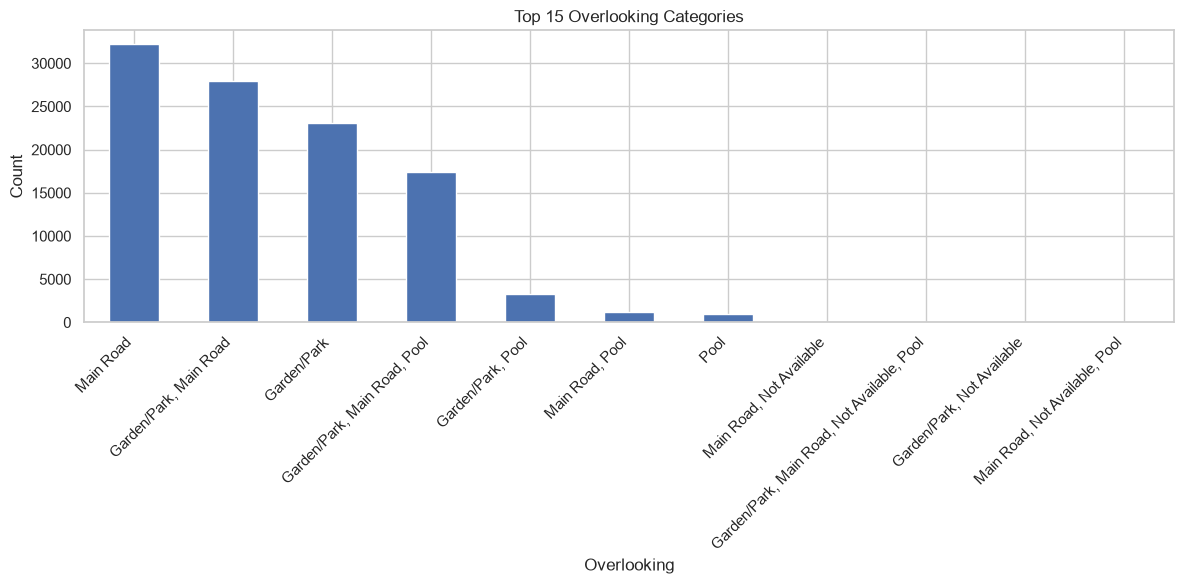

In [83]:
overlooking_counts = df["overlooking"].value_counts().head(15)

plt.figure(figsize=(12, 6))
overlooking_counts.plot(kind="bar")

plt.title("Top 15 Overlooking Categories")
plt.xlabel("Overlooking")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Standardizing Overlooking Categories

Some overlooking categories contain the same views but in different orders.

For example:

- Garden/Park, Main Road
- Main Road, Garden/Park

These represent the same information.

To avoid creating duplicate categories, the values will be standardized by sorting the individual views alphabetically.

In [79]:
def normalize_overlooking(value):
    if pd.isna(value):
        return value

    parts = [item.strip() for item in value.split(",")]
    parts = sorted(parts)

    return ", ".join(parts)


df["overlooking"] = df["overlooking"].apply(normalize_overlooking)

print("Unique categories after cleaning:")
print(df["overlooking"].nunique())

print()

print(df["overlooking"].value_counts(dropna=False).head(20))

Unique categories after cleaning:
11

overlooking
NaN                                            81436
Main Road                                      32193
Garden/Park, Main Road                         27904
Garden/Park                                    23077
Garden/Park, Main Road, Pool                   17440
                                               ...  
Pool                                            1012
Main Road, Not Available                           4
Garden/Park, Main Road, Not Available, Pool        1
Garden/Park, Not Available                         1
Main Road, Not Available, Pool                     1
Name: count, Length: 12, dtype: int64


### Observation

- The feature contains **43.43% missing values**, which is relatively high.

- After standardizing the order of multiple overlooking views, the number of unique categories decreased from **19** to **11**, indicating that several duplicate categories were successfully merged.

- The most common overlooking types are **Main Road**, **Garden/Park**, and the combination of **Garden/Park and Main Road**.

- Properties overlooking multiple amenities (such as Garden/Park, Main Road, and Pool) also appear frequently.

- Despite the missing values, overlooking characteristics may provide useful information for predicting house prices, so the feature will be retained for later preprocessing and modeling.

## Location Analysis

The **Location** feature represents the city where each property is located.

Location is expected to be one of the most influential factors affecting house prices because property values vary significantly across different cities.

We will examine:

- Number of unique locations
- Distribution of properties across cities
- Most common locations
- Rare locations
- Relationship between location and house prices

In [80]:
# Basic statistics for the location feature

print(f"Missing values : {df['location'].isna().sum():,}")
print(f"Missing (%)    : {(df['location'].isna().mean() * 100):.2f}%")

print(f"\nUnique locations : {df['location'].nunique()}")

print("\nTop 20 locations:\n")
print(df["location"].value_counts().head(20))

Missing values : 0
Missing (%)    : 0.00%

Unique locations : 81

Top 20 locations:

location
new-delhi        27599
bangalore        24030
kolkata          22380
gurgaon          20070
ahmedabad        12750
                 ...  
visakhapatnam     1800
mohali            1710
zirakpur          1530
chandigarh        1440
noida             1281
Name: count, Length: 20, dtype: int64


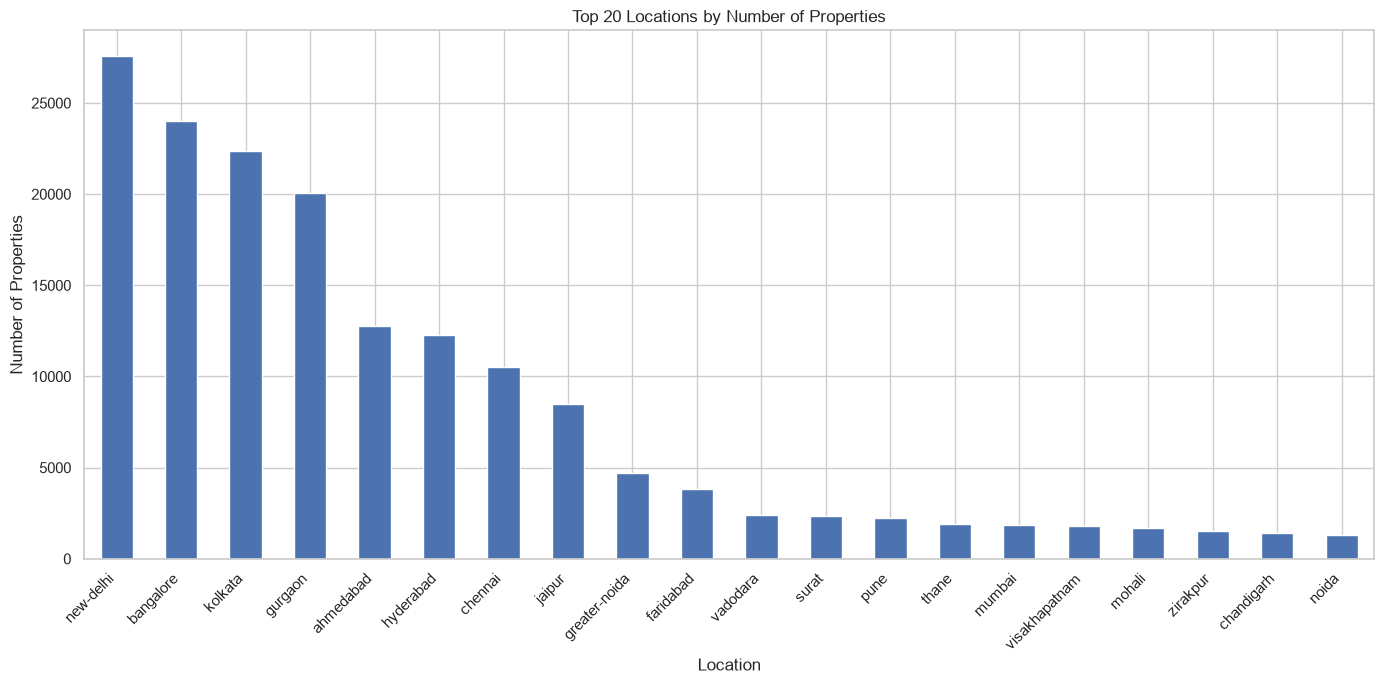

In [82]:
top_locations = df["location"].value_counts().head(20)

plt.figure(figsize=(14, 7))
top_locations.plot(kind="bar")

plt.title("Top 20 Locations by Number of Properties")
plt.xlabel("Location")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [87]:
# Number of cities with very few properties

location_counts = df["location"].value_counts()

print("Locations with only one property :", (location_counts == 1).sum())
print("Locations with fewer than 10 properties :", (location_counts < 10).sum())
print("Locations with fewer than 50 properties :", (location_counts < 50).sum())

Locations with only one property : 0
Locations with fewer than 10 properties : 0
Locations with fewer than 50 properties : 7


In [88]:
# Cities with fewer than 50 properties

rare_locations = location_counts[location_counts < 50]

rare_locations

location
ahmadnagar     30
madurai        30
navsari        30
nellore        30
palakkad       30
pondicherry    30
solapur        30
Name: count, dtype: int64

### Observation

- The **Location** feature contains **no missing values**, making it one of the highest-quality features in the dataset.

- The dataset contains **81 unique cities**, providing broad geographical coverage while remaining manageable for machine learning.

- Property listings are unevenly distributed across cities, with **New Delhi**, **Bangalore**, **Kolkata**, and **Gurgaon** contributing the largest number of properties.

- Only **7 cities** contain fewer than **50** properties, and each of these cities has exactly **30** listings. This suggests that the imbalance is due to dataset collection rather than data quality issues.

- Since location is one of the strongest factors influencing house prices, this feature will be retained without modification and will play an important role during model training.

## Relationship Between Location and House Prices

Location is one of the most important factors affecting real estate prices.

In this section, we analyze the **average property price** for each city to identify:

- The most expensive locations
- The least expensive locations
- Geographic differences in housing prices

In [89]:
# Average house price by location

location_price = (
    df.groupby("location")["Price_INR"]
      .mean()
      .sort_values(ascending=False)
)

location_price.head(10)

location
mumbai         3.355292e+07
gurgaon        2.170470e+07
siliguri       1.803144e+07
panchkula      1.712139e+07
raipur         1.638794e+07
new-delhi      1.616784e+07
hyderabad      1.526815e+07
chennai        1.139704e+07
noida          1.122650e+07
navi-mumbai    1.102281e+07
Name: Price_INR, dtype: float64

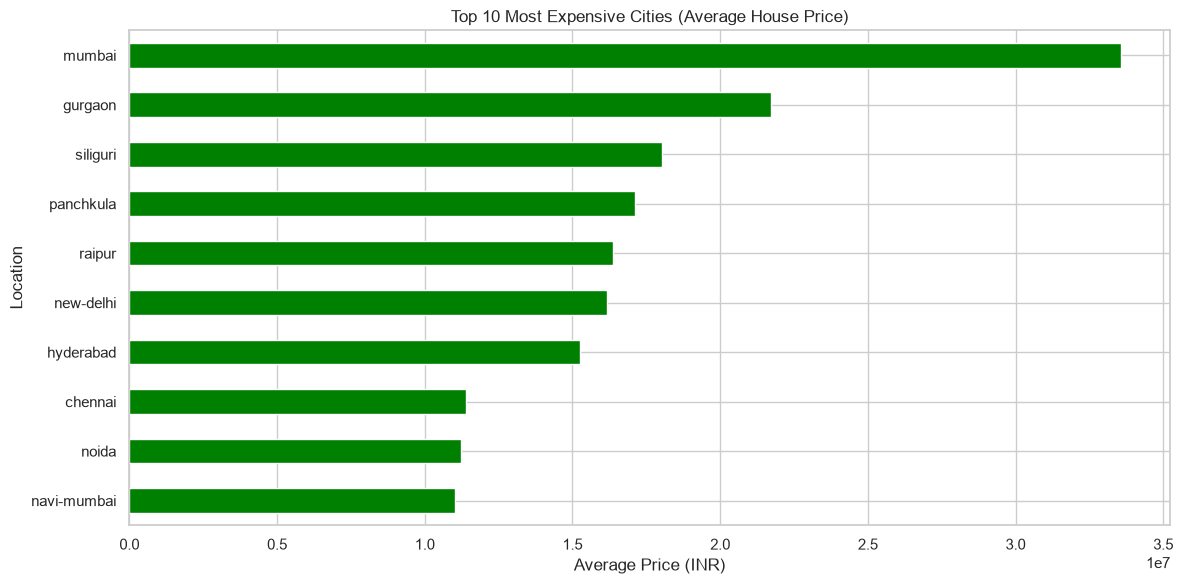

In [90]:
plt.figure(figsize=(12,6))

location_price.head(10).sort_values().plot(kind="barh",color='green')

plt.title("Top 10 Most Expensive Cities (Average House Price)")
plt.xlabel("Average Price (INR)")
plt.ylabel("Location")

plt.tight_layout()

plt.show()

In [91]:
location_price.tail(10)

location
satara      3.599831e+06
solapur     3.430000e+06
bhopal      3.403729e+06
durgapur    3.373041e+06
haridwar    3.144802e+06
badlapur    3.001959e+06
vapi        2.855302e+06
palghar     2.730685e+06
bhiwadi     2.724763e+06
navsari     2.713667e+06
Name: Price_INR, dtype: float64

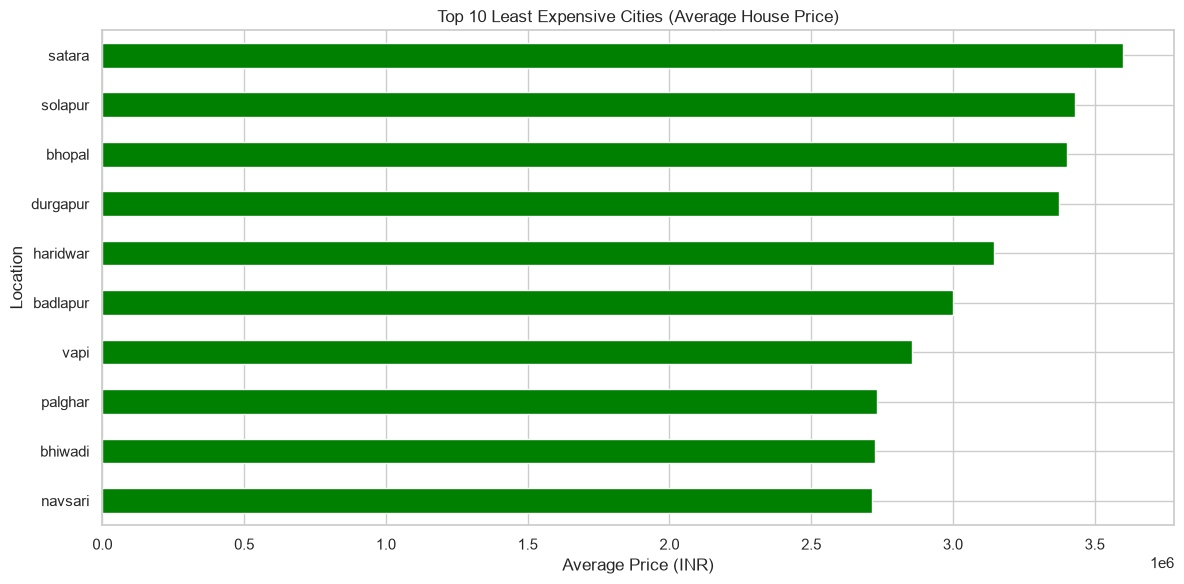

In [92]:
plt.figure(figsize=(12,6))

location_price.tail(10).sort_values().plot(kind="barh",color='green')

plt.title("Top 10 Least Expensive Cities (Average House Price)")
plt.xlabel("Average Price (INR)")
plt.ylabel("Location")

plt.tight_layout()

plt.show()

### Observation

- Property prices vary significantly across different cities, confirming that **location is a major factor influencing house prices**.

- **Mumbai** has the highest average property price in the dataset, followed by **Gurgaon**, **Siliguri**, **Panchkula**, and **Raipur**.

- Cities such as **Navsari**, **Bhiwadi**, **Palghar**, and **Vapi** have the lowest average property prices.

- The large variation in average prices across cities indicates that the **Location** feature is expected to have strong predictive power and should contribute significantly to the final machine learning model.

- These findings are consistent with real-world real estate markets, where metropolitan areas generally have higher property values than smaller cities.

## Correlation Analysis

To better understand the relationships between numerical variables, a correlation matrix is computed using only meaningful numerical features.

Identifier columns, duplicate target representations, and empty features are excluded to produce a clearer analysis.

The correlation coefficient ranges from **-1** to **1**, where:

- **1** indicates a perfect positive relationship.
- **0** indicates no linear relationship.
- **-1** indicates a perfect negative relationship.

In [100]:
correlation_features = [
    "Price_INR",
    "Log_Price",
    "Bathroom",
    "Balcony",
    "Carpet_Area_sqft",
    "Super_Area_sqft"
]

corr_matrix = df[correlation_features].corr()

corr_matrix

,Price_INR,Log_Price,Bathroom,Balcony,Carpet_Area_sqft,Super_Area_sqft
Price_INR,1.000000,0.306236,0.214631,0.102851,0.205966,0.646409
Log_Price,0.306236,1.000000,0.720731,0.409071,0.750724,0.661139
Bathroom,0.214631,0.720731,1.000000,0.404723,0.802019,0.751587
Balcony,0.102851,0.409071,0.404723,1.000000,0.344112,0.373741
Carpet_Area_sqft,0.205966,0.750724,0.802019,0.344112,1.000000,NaN
Super_Area_sqft,0.646409,0.661139,0.751587,0.373741,NaN,1.000000


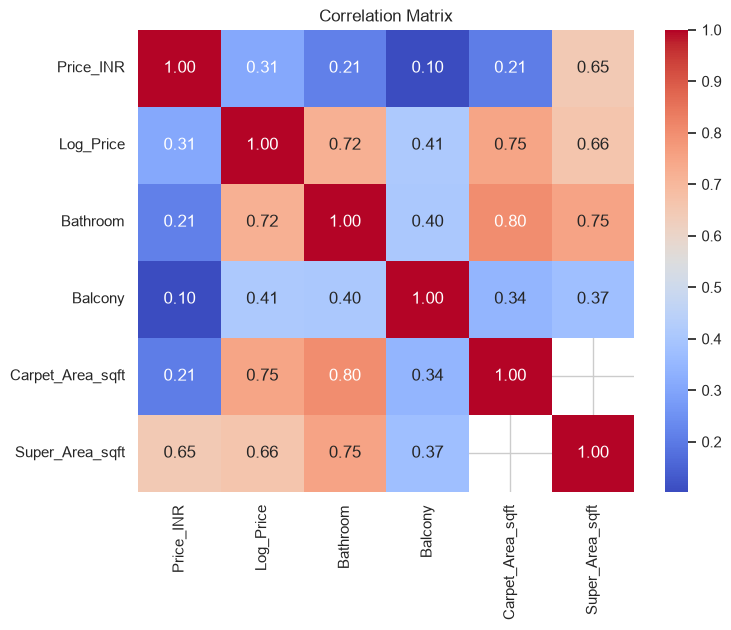

In [102]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [103]:
corr_matrix["Price_INR"].sort_values(ascending=False)

Price_INR           1.000000
Super_Area_sqft     0.646409
Log_Price           0.306236
Bathroom            0.214631
Carpet_Area_sqft    0.205966
Balcony             0.102851
Name: Price_INR, dtype: float64

### Observation

- **Super Area** has the strongest positive correlation with the target variable (**0.65**), indicating that larger built-up properties generally have higher prices.

- **Bathroom** and **Carpet Area** show weak to moderate positive correlations, suggesting they contribute to house prices but are not the primary driving factors.

- **Balcony** has only a weak positive relationship with property prices.

- The relatively lower correlation of **Carpet Area** is likely influenced by the high percentage of missing values and the removal of invalid measurements during data cleaning.

- Overall, the analysis indicates that **property size** is the most influential numerical feature among those examined.

- Many important predictors in this dataset are categorical (such as **Location**, **Furnishing**, **Transaction**, and **Ownership**). Therefore, correlation analysis alone does not capture all the relationships that will be learned by the machine learning models.

# Feature vs Target Analysis

In this section, we investigate how important property characteristics influence house prices.

Unlike the previous exploratory analysis, these visualizations directly compare each feature with the target variable (**Price_INR**) to understand which features have the greatest impact on property prices.

The analysis focuses on the most informative numerical and categorical features.

## Furnishing vs House Price

Furnished properties generally provide more convenience and are expected to have higher market values than semi-furnished or unfurnished properties.

We compare the distribution of house prices across different furnishing levels.

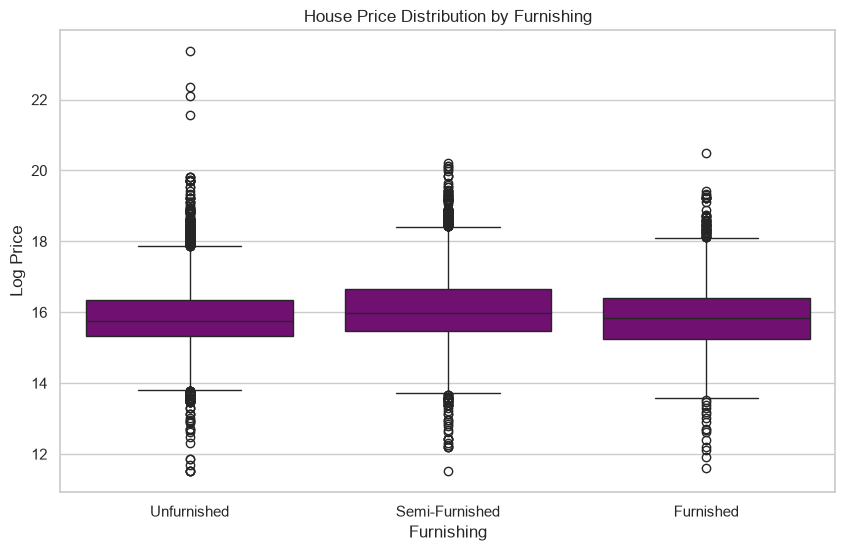

In [105]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="Log_Price",
    order=["Unfurnished", "Semi-Furnished", "Furnished"],
    color='purple'

)

plt.title("House Price Distribution by Furnishing")
plt.xlabel("Furnishing")
plt.ylabel("Log Price")

plt.show()

In [106]:
df.groupby("Furnishing")["Price_INR"].agg(["count", "mean", "median"]).sort_values(
    by="mean",
    ascending=False
)

,count,mean,median
Furnishing,,,
Semi-Furnished,82868,1.283528e+07,8750000.0
Unfurnished,73491,1.137175e+07,7000000.0
Furnished,19421,1.102939e+07,7500000.0


### Observation

- Semi-furnished properties have the highest average and median selling prices in this dataset.

- Furnished and unfurnished properties show broadly similar price distributions, although both have lower average prices than semi-furnished properties.

- The distributions contain many high-value outliers, indicating that furnishing alone is not sufficient to explain house prices.

- This suggests that other factors such as location, property size, and property type likely have a stronger influence on price than furnishing status alone.

## Transaction Type vs House Price

The transaction type indicates whether a property is being sold as a resale property or as a newly constructed property.

Comparing transaction categories helps determine whether newly developed properties tend to command higher prices than resale properties.

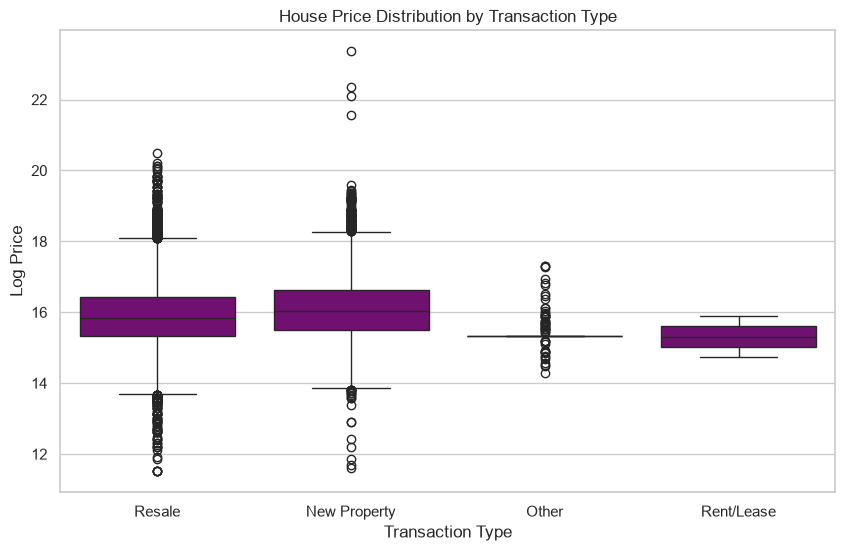

In [108]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Transaction",
    y="Log_Price",
    color='purple'
)

plt.title("House Price Distribution by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Log Price")

plt.show()

In [109]:
df.groupby("Transaction")["Price_INR"].agg(
    ["count", "mean", "median"]
).sort_values(by="mean", ascending=False)

,count,mean,median
Transaction,,,
New Property,41445,1.550854e+07,9300000.0
Resale,135630,1.094314e+07,7500000.0
Rent/Lease,2,5.250000e+06,5250000.0
Other,703,4.785818e+06,4500000.0


### Observation

- New properties have substantially higher average and median prices than resale properties.

- This suggests that newly constructed homes generally command a price premium in the housing market.

- The **Resale** category contains the largest number of properties and exhibits a wider range of prices.

- The **Other** and **Rent/Lease** categories contain very few observations, making them less reliable for drawing meaningful conclusions.

- Overall, **Transaction Type** appears to be an informative categorical feature for predicting house prices.

## Location vs House Price

Property prices vary significantly across cities due to differences in demand, infrastructure, economic activity, and local housing markets.

To keep the visualization readable, we compare the price distributions of the **15 locations with the largest number of properties** in the dataset.

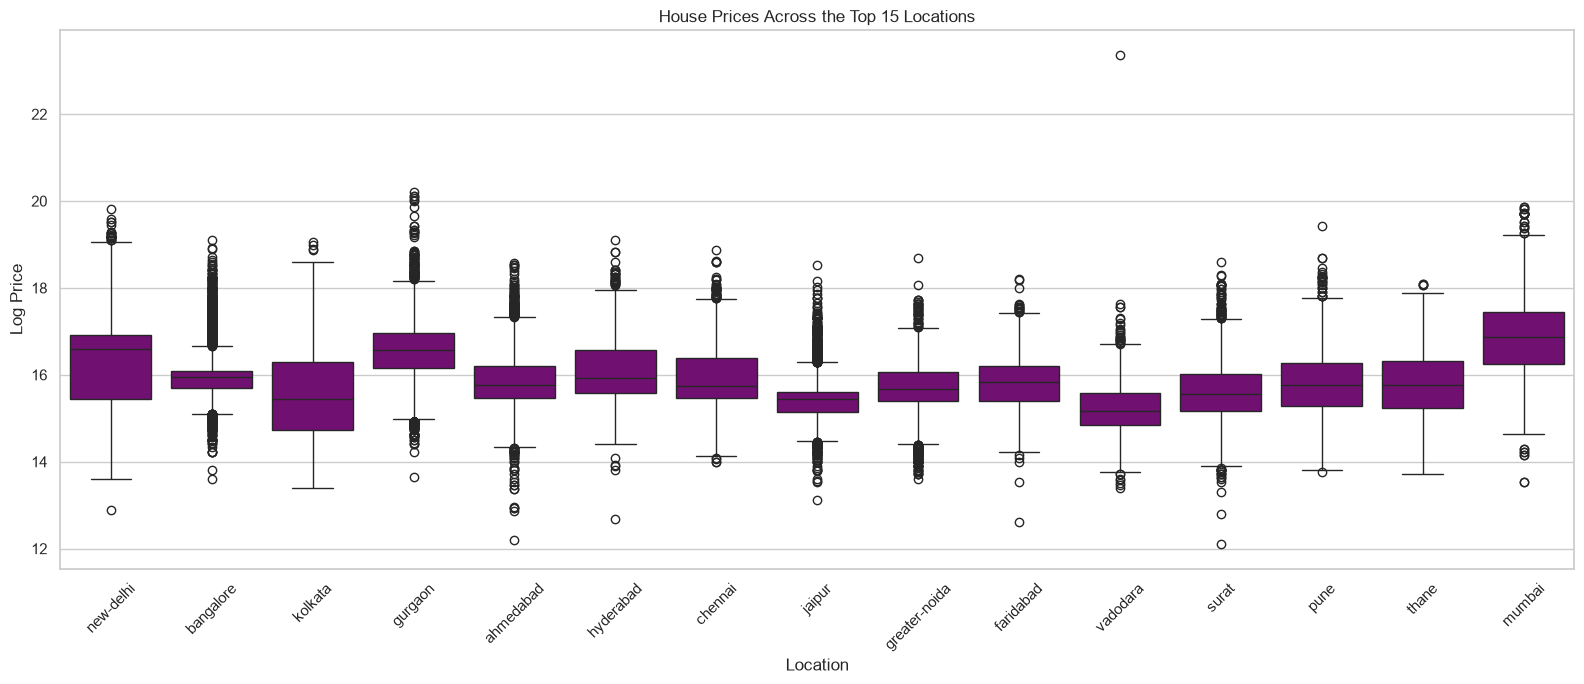

In [111]:
top_locations = df["location"].value_counts().head(15).index

plt.figure(figsize=(16,7))

sns.boxplot(
    data=df[df["location"].isin(top_locations)],
    x="location",
    y="Log_Price",
    order=top_locations,
    color='purple'
)

plt.xticks(rotation=45)
plt.title("House Prices Across the Top 15 Locations")
plt.xlabel("Location")
plt.ylabel("Log Price")

plt.tight_layout()
plt.show()

In [112]:
location_summary = (
    df.groupby("location")["Price_INR"]
      .agg(["count", "mean", "median"])
      .sort_values("count", ascending=False)
)

location_summary.head(15)

,count,mean,median
location,,,
new-delhi,24945,1.616784e+07,16000000.0
bangalore,23262,1.006305e+07,8500000.0
kolkata,21605,8.707460e+06,5100000.0
gurgaon,18846,2.170470e+07,15700000.0
ahmedabad,12614,1.027555e+07,7000000.0
...,...,...,...
vadodara,2361,1.082852e+07,3900000.0
surat,2180,8.449050e+06,5685000.0
pune,2177,1.052901e+07,7000000.0


### Observation

- Property prices vary considerably across different cities, indicating that **location is one of the strongest factors affecting house prices.**

- Mumbai has the highest average property prices among the major cities, followed by Gurgaon and New Delhi.

- Cities such as Kolkata, Pune, and Thane generally have lower average property prices compared to the most expensive metropolitan areas.

- Nearly every city contains high-value outliers, suggesting that luxury properties exist across multiple housing markets.

- The large variation in price distributions confirms that **Location** will be an important feature for the machine learning models.

# Final Feature Selection

After completing the exploratory data analysis, we now prepare the dataset for machine learning.

At this stage we decide:

- Which columns should be used as model features.
- Which columns should be removed.
- Which column will be used as the prediction target.

The goal is to keep informative features while removing identifiers, duplicated information, and columns that cannot contribute to prediction.

In [113]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area', 'Price_INR', 'Log_Price', 'Carpet_Area_sqft',
       'Super_Area_sqft'],
      dtype='str')

## Selecting Features

Not every column should be used for model training.

Some columns are identifiers, some are duplicated representations of other features, while others contain almost no useful information.

We first classify every feature before removing unnecessary columns.

In [114]:
feature_roles = pd.DataFrame({
    "Feature": df.columns
})

feature_roles

,Feature
0,Index
1,Title
2,Description
3,Amount(in rupees)
4,Price (in rupees)
...,...
20,Plot Area
21,Price_INR
22,Log_Price
23,Carpet_Area_sqft


In [115]:
feature_roles["Decision"] = [
    "Drop",          # Index
    "Keep",          # Title
    "Keep",          # Description
    "Drop",          # Amount(in rupees)
    "Drop",          # Price (in rupees)
    "Keep",          # location
    "Drop",          # Carpet Area
    "Drop",          # Status
    "Keep",          # Floor
    "Keep",          # Transaction
    "Keep",          # Furnishing
    "Keep",          # facing
    "Keep",          # overlooking
    "Keep",          # Society
    "Keep",          # Bathroom
    "Keep",          # Balcony
    "Keep",          # Car Parking
    "Keep",          # Ownership
    "Drop",          # Super Area
    "Drop",          # Dimensions
    "Drop",          # Plot Area
    "Target",        # Price_INR
    "Drop",          # Log_Price
    "Keep",          # Carpet_Area_sqft
    "Keep"           # Super_Area_sqft
]

feature_roles

,Feature,Decision
0,Index,Drop
1,Title,Keep
2,Description,Keep
3,Amount(in rupees),Drop
4,Price (in rupees),Drop
...,...,...
20,Plot Area,Drop
21,Price_INR,Target
22,Log_Price,Drop
23,Carpet_Area_sqft,Keep


### Why these decisions?

- **Index** is only an identifier and has no predictive value.

- **Amount(in rupees)** is the original target stored as text. It was converted into the numerical target (`Price_INR`).

- **Price (in rupees)** represents price per square foot, which is calculated using the selling price. Using it would introduce information leakage because it already contains knowledge of the target.

- **Status** has only one category ("Ready to Move"), so it provides no useful information.

- **Carpet Area** and **Super Area** were converted into numerical versions, making the original text columns unnecessary.

- **Dimensions** and **Plot Area** contain only missing values and therefore cannot contribute to prediction.

- **Log_Price** was created only for exploratory analysis and visualization. The final model will predict the actual house price (`Price_INR`).

In [116]:
selected_features = [
    "Title",
    "Description",
    "location",
    "Floor",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Society",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "Ownership",
    "Carpet_Area_sqft",
    "Super_Area_sqft"
]

target = "Price_INR"

print(f"Number of features: {len(selected_features)}")
print(f"Target: {target}")

Number of features: 15
Target: Price_INR


In [117]:
model_df = df[selected_features + [target]].copy()

print(model_df.shape)

model_df.head()

(187531, 16)


,Title,Description,location,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Carpet_Area_sqft,Super_Area_sqft,Price_INR
0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",thane,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,500.0,NaN,4200000.0
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,thane,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,NaN,1 Open,Freehold,473.0,NaN,9800000.0
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,thane,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,NaN,1 Covered,Freehold,779.0,NaN,14000000.0
3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,thane,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1.0,1.0,NaN,NaN,530.0,NaN,2500000.0
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",thane,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,NaN,1 Covered,Co-operative Society,635.0,NaN,16000000.0


### Observation

- A new dataset (`model_df`) was created containing only the selected features and the prediction target.

- This dataset will be used throughout the preprocessing, feature engineering, and model training stages.

- Keeping a separate modeling dataset preserves the original data and makes the workflow cleaner and easier to maintain.

# Missing Value Strategy

Before imputing missing values, we first analyze how much data is missing in each selected feature.

Understanding the missing-data pattern helps us choose the most appropriate imputation strategy instead of blindly filling values.

Different features require different treatments depending on:

- Percentage of missing values
- Feature type
- Business meaning

In [118]:
missing_summary = pd.DataFrame({
    "Missing Values": model_df.isna().sum(),
    "Missing (%)": (model_df.isna().mean() * 100).round(2),
    "Data Type": model_df.dtypes.astype(str)
})

missing_summary = (
    missing_summary
    .sort_values("Missing (%)", ascending=False)
    .reset_index()
    .rename(columns={"index": "Feature"})
)

missing_summary

,Feature,Missing Values,Missing (%),Data Type
0,Super_Area_sqft,112169,59.81,float64
1,Society,109678,58.49,str
2,Car Parking,103357,55.11,str
3,Carpet_Area_sqft,88107,46.98,float64
4,overlooking,81436,43.43,str
...,...,...,...,...
11,Furnishing,2897,1.54,str
12,Bathroom,863,0.46,float64
13,Transaction,83,0.04,str
14,Title,0,0.00,str


# Missing Value Handling Plan

Each feature will be handled according to its characteristics rather than applying the same strategy to all columns.

In [119]:
preprocessing_plan = pd.DataFrame({
    "Feature": selected_features,
    "Strategy": [
        "Keep (Text)",
        "Keep (Text)",
        "Keep",
        "Feature Engineering",
        "Mode",
        "Mode",
        "Unknown Category",
        "Unknown Category",
        "Missing Category",
        "Median",
        "Median",
        "Missing Category",
        "Missing Category",
        "Median",
        "Median"
    ]
})

preprocessing_plan

,Feature,Strategy
0,Title,Keep (Text)
1,Description,Keep (Text)
2,location,Keep
3,Floor,Feature Engineering
4,Transaction,Mode
...,...,...
10,Balcony,Median
11,Car Parking,Missing Category
12,Ownership,Missing Category
13,Carpet_Area_sqft,Median


### Why these strategies?

- **Text features** will be preserved because they contain valuable information that can later be transformed into engineered features.

- **Floor** will not be imputed directly because useful numerical information can be extracted from it.

- **Categorical features** with missing values will receive an explicit category (for example, `"Unknown"` or `"Missing"`), allowing the model to learn from the absence of information.

- **Numerical features** will use median imputation since the distributions are skewed and contain outliers.

# Feature Engineering

## Extracting the Number of Bedrooms (BHK)

The property title contains structured information describing the number of bedrooms.

Examples include:

- 1 BHK
- 2 BHK
- 4 BHK
- Studio Apartment
- > 10 BHK

Instead of using the entire title, we extract the bedroom count as a numerical feature that can be used directly by machine learning models.

In [120]:
import re

def extract_bhk(title):
    """
    Extract the number of bedrooms from the property title.
    """

    if pd.isna(title):
        return np.nan

    title = str(title)

    # Handle Studio Apartments
    if "Studio" in title:
        return 0

    # Handle '> 10 BHK'
    if "> 10 BHK" in title:
        return 10

    match = re.search(r'(\d+)\s*BHK', title)

    if match:
        return int(match.group(1))

    return np.nan

In [121]:
model_df["BHK"] = model_df["Title"].apply(extract_bhk)

model_df[["Title", "BHK"]].head(10)

,Title,BHK
0,1 BHK Ready to Occupy Flat for sale in Srushti...,1.0
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,2.0
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,2.0
3,1 BHK Ready to Occupy Flat for sale Kasheli,1.0
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,2.0
5,1 BHK Ready to Occupy Flat for sale in Virat A...,1.0
6,1 BHK Ready to Occupy Flat for sale Mumbra,1.0
7,1 BHK Ready to Occupy Flat for sale Kalwa,1.0
8,1 BHK Ready to Occupy Flat for sale Kalwa,1.0
9,3 BHK Ready to Occupy Flat for sale in Pride P...,3.0


In [122]:
print("Missing values :", model_df["BHK"].isna().sum())
print(f"Missing (%) : {model_df['BHK'].isna().mean()*100:.2f}%")

print("\nValue Counts:\n")

print(model_df["BHK"].value_counts().sort_index())

Missing values : 31
Missing (%) : 0.02%

Value Counts:

BHK
0.0       901
1.0     12275
2.0     75506
3.0     80848
4.0     16600
        ...  
6.0        98
7.0        22
8.0        17
9.0         7
10.0       43
Name: count, Length: 11, dtype: int64


In [123]:
model_df["BHK"].describe()

count    187500.000000
mean          2.557424
std           0.804452
min           0.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          10.000000
Name: BHK, dtype: float64

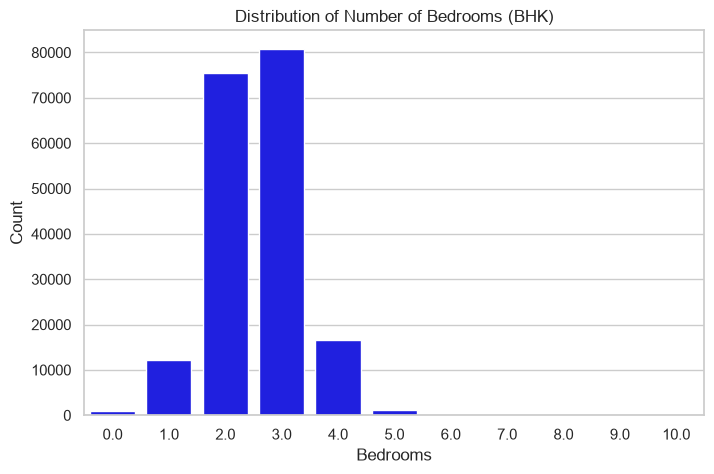

In [125]:
plt.figure(figsize=(8,5))

sns.countplot(data=model_df, x="BHK",color='blue')

plt.title("Distribution of Number of Bedrooms (BHK)")
plt.xlabel("Bedrooms")
plt.ylabel("Count")

plt.show()

In [126]:
model_df.groupby("BHK")["Price_INR"].agg(["count", "mean", "median"])

,count,mean,median
BHK,,,
0.0,315,7.099079e+06,2500000.0
1.0,10717,3.531605e+06,2500000.0
2.0,70474,6.213945e+06,5300000.0
3.0,78674,1.378458e+07,10500000.0
4.0,16336,3.064698e+07,26800000.0
...,...,...,...
6.0,92,7.038696e+07,41000000.0
7.0,21,5.689524e+07,39600000.0
8.0,16,2.089850e+08,192500000.0


In [127]:
model_df.loc[
    model_df["BHK"].isna(),
    ["Title"]
]

,Title
293,Apartment for sale Kisan Nagar
2580,Apartment for sale in Shivam Parivar Sidhivin...
5277,"Apartment for sale South Bopal, Bopal"
16424,Apartment for sale S R Layout Murgesh Pallya
16601,Apartment for sale S R Layout Murgesh Pallya
...,...
176123,Apartment for sale South Office Para
180519,Apartment for sale Poojapura
184583,Apartment for sale Madhavadhara
185185,Apartment for sale in Bhoomatha Radhika Resid...


In [128]:
model_df["BHK"] = model_df["BHK"].astype("Int64")

model_df["BHK"].dtype

Int64Dtype()

### Observation

- The number of bedrooms (**BHK**) was successfully extracted from the property titles.

- The feature contains only **31 missing values (0.02%)**, indicating that almost all property titles follow a consistent naming pattern.

- Most properties are **2 BHK** and **3 BHK**, which together represent the majority of listings in the dataset.

- Property prices generally increase with the number of bedrooms, confirming that **BHK is a highly informative feature for predicting house prices**.

- The small number of missing values will be handled later during preprocessing.